# 1. Importar librerías

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="darkgrid",
    palette="pastel",
    font="sans-serif",
    rc={"grid.linestyle": "--", "axes.edgecolor": "0.8"}
)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

seed = 25

# 2. Importar Dataset

**Datasets a importar:**

`train_features (train set values)` : variables independientes del conjunto train

`train_labels (train set labels)` : variable dependiente del conjunto train 

`test_features (test set values)` : variables independientes del conjunto test (objetivo a predecir) 

In [2]:
# Importar features
train_features = pd.read_csv('train set values.csv')
train_features.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [3]:
# Importar target
train_labels = pd.read_csv('train set labels.csv')
train_labels.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


In [4]:
# Importar conjunto test
test_features = pd.read_csv('test set values.csv')
test_features.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,Internal,Magoma,Manyara,21,3,Mbulu,Bashay,321,True,GeoData Consultants Ltd,Parastatal,NaN,True,2012,other,other,other,parastatal,parastatal,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,Pangani,Kimnyak,Arusha,2,2,Arusha Rural,Kimnyaki,300,True,GeoData Consultants Ltd,VWC,TPRI pipe line,True,2000,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,Internal,Msatu,Singida,13,2,Singida Rural,Puma,500,True,GeoData Consultants Ltd,VWC,P,NaN,2010,other,other,other,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,Ruvuma / Southern Coast,Kipindimbi,Lindi,80,43,Liwale,Mkutano,250,NaN,GeoData Consultants Ltd,VWC,NaN,True,1987,other,other,other,vwc,user-group,unknown,unknown,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,Ruvuma / Southern Coast,Losonga,Ruvuma,10,3,Mbinga,Mbinga Urban,60,NaN,GeoData Consultants Ltd,Water Board,BRUDER,True,2000,gravity,gravity,gravity,water board,user-group,pay monthly,monthly,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe


La variable dependiente y las variables independientes están en DataFrames distintos, con el objetivo de ser más eficiente en el código, se hace un merge de ambos DataFrames del conjunto train. Antes de realizar un merge a partir de 'id', se comprueba que los ids coinciden exactamente entre ambos.

In [5]:
# Comparar número de filas
print(train_features.shape, train_labels.shape)

(59400, 40) (59400, 2)


In [6]:
# Comprobar duplicados para evitar multiplicación de filas
train_features['id'].duplicated().sum()
train_labels['id'].duplicated().sum()

np.int64(0)

In [7]:
# Comprobar que los ids son los mismos en ambos
set(train_features['id']) == set(train_labels['id'])

True

### Unión de features y target
Ambos DataFrames tienen los mismos ids, por lo que se pueden combinar en uno solo. El nuevo DataFrame se denominará df.

**Nota sobre nomenclatura:** no se llama a este DataFrame train, para evitar confusión más adelante. El conjunto que DrivenData proporciona como "train" (`train_set_values.csv` + `train_set_labels.csv`) es el único conjunto del que se dispone y a partir de él se genera posteriormente una   división propia en train/validation (o mediante validación cruzada) para evaluar los modelos antes de aplicarlos al conjunto de test real de la competición.

Es decir, se distingue dos niveles de "train/test":
- **Train/Test de la competición**: df (con target conocido) y test_values (sin target, es el que hay que predecir para el submission final).
- **Train/Validation internos**: la división que haremos sobre df más adelante, para poder medir el rendimiento de los modelos de forma honesta antes de aplicarlos al test real.

In [8]:
# Combinar DataFrames de train
df = train_features.merge(train_labels, on="id")
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


# 3. EDA

## Análisis general

In [9]:
# Número de filas y columnas
df.shape

(59400, 41)

In [10]:
# Identificar variables, tipo de datos y nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [11]:
# Estadísticos de variables numéricas
df.describe()

,id,amount_tsh,gps_height,longitude,latitude,num_private,region_code,district_code,population,construction_year
count,59400.000000,59400.000000,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000,59400.000000,59400.000000,59400.000000
mean,37115.131768,317.650385,668.297239,34.077427,-5.706033e+00,0.474141,15.297003,5.629747,179.909983,1300.652475
std,21453.128371,2997.574558,693.116350,6.567432,2.946019e+00,12.236230,17.587406,9.633649,471.482176,951.620547
min,0.000000,0.000000,-90.000000,0.000000,-1.164944e+01,0.000000,1.000000,0.000000,0.000000,0.000000
25%,18519.750000,0.000000,0.000000,33.090347,-8.540621e+00,0.000000,5.000000,2.000000,0.000000,0.000000
50%,37061.500000,0.000000,369.000000,34.908743,-5.021597e+00,0.000000,12.000000,3.000000,25.000000,1986.000000
75%,55656.500000,20.000000,1319.250000,37.178387,-3.326156e+00,0.000000,17.000000,5.000000,215.000000,2004.000000
max,74247.000000,350000.000000,2770.000000,40.345193,-2.000000e-08,1776.000000,99.000000,80.000000,30500.000000,2013.000000


In [12]:
# Estadísticos de variables categóricas
df.describe(include='str')

,date_recorded,funder,installer,wpt_name,basin,subvillage,region,lga,ward,recorded_by,scheme_management,scheme_name,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
count,59400,55763,55745,59398,59400,59029,59400,59400,59400,59400,55522,30590,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400,59400
unique,356,1896,2145,37399,9,19287,21,125,2092,1,11,2695,18,13,7,12,5,7,7,8,6,5,5,10,7,3,7,6,3
top,2011-03-15,Government Of Tanzania,DWE,none,Lake Victoria,Madukani,Iringa,Njombe,Igosi,GeoData Consultants Ltd,VWC,K,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
freq,572,9084,17402,3563,10248,508,5294,2503,307,59400,36793,682,26780,26780,26780,40507,52490,25348,25348,50818,50818,33186,33186,17021,17021,45794,28522,34625,32259


In [13]:
# Número de duplicados
df.duplicated().sum()

np.int64(0)

In [14]:
# Número de duplicados (ignorando el id)
df.drop(columns='id').duplicated().sum()

np.int64(36)

In [15]:
# DataFrame de duplicados
duplicados = df.drop(columns="id").duplicated(keep=False)

df[duplicados].sort_values(by=["date_recorded"])

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
39187,18713,0.0,2011-07-13,He,0,HE,31.61953,-1.793342e+00,Kahindu,0,Lake Victoria,Ikondoa,Kagera,18,3,Muleba,Ikondo,0,True,GeoData Consultants Ltd,VWC,NaN,True,0,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,improved spring,improved spring,functional
17451,29553,0.0,2011-07-13,He,0,HE,31.61953,-1.793342e+00,Kahindu,0,Lake Victoria,Ikondoa,Kagera,18,3,Muleba,Ikondo,0,True,GeoData Consultants Ltd,VWC,NaN,True,0,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,enough,enough,spring,spring,groundwater,improved spring,improved spring,functional
301,70379,0.0,2011-07-18,Government Of Tanzania,0,Government,0.00000,-2.000000e-08,Nersing College,0,Lake Victoria,Nyanza,Mwanza,19,6,Geita,Kalangalala,0,True,GeoData Consultants Ltd,VWC,Borehole,True,0,afridev,afridev,handpump,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,machine dbh,borehole,groundwater,hand pump,hand pump,functional
326,7900,0.0,2011-07-18,Government Of Tanzania,0,Government,0.00000,-2.000000e-08,Hospital,0,Lake Victoria,Nyanza,Mwanza,19,6,Geita,Kalangalala,0,True,GeoData Consultants Ltd,VWC,Kalangalala,True,0,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,machine dbh,borehole,groundwater,communal standpipe,communal standpipe,functional
28518,68204,0.0,2011-07-18,Government Of Tanzania,0,Government,0.00000,-2.000000e-08,Hospital,0,Lake Victoria,Nyanza,Mwanza,19,6,Geita,Kalangalala,0,True,GeoData Consultants Ltd,VWC,Kalangalala,True,0,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,insufficient,insufficient,machine dbh,borehole,groundwater,communal standpipe,communal standpipe,functional
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55874,31157,0.0,2013-02-16,Dwsp,0,DWE,0.00000,-2.000000e-08,Igolola,0,Lake Victoria,Busumagu,Mwanza,17,1,Magu,Nkungulu,0,NaN,GeoData Consultants Ltd,WUG,NaN,False,0,nira/tanira,nira/tanira,handpump,wug,user-group,unknown,unknown,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,functional
6611,31684,0.0,2013-02-16,Dwsp,0,DWE,0.00000,-2.000000e-08,Sango,0,Lake Victoria,Nduhu,Mwanza,17,1,Magu,Nkungulu,0,NaN,GeoData Consultants Ltd,WUG,NaN,False,0,nira/tanira,nira/tanira,handpump,wug,user-group,unknown,unknown,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,functional
323,51403,0.0,2013-02-16,Dwsp,0,DWE,0.00000,-2.000000e-08,Serengeti,0,Lake Victoria,Madukani,Mwanza,17,1,Magu,Nkungulu,0,NaN,GeoData Consultants Ltd,WUG,NaN,False,0,other,other,other,wug,user-group,unknown,unknown,soft,good,enough,enough,other,other,unknown,other,other,non functional
13823,8342,0.0,2013-02-16,Pmo,0,DWE,0.00000,-2.000000e-08,Muungano,0,Lake Victoria,Madukani,Mwanza,17,1,Magu,Nkungulu,0,NaN,GeoData Consultants Ltd,WUG,NaN,False,0,nira/tanira,nira/tanira,handpump,wug,user-group,unknown,unknown,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,functional needs repair


In [16]:
# Eliminar duplicados
df = df.drop_duplicates(subset=[c for c in df.columns if c not in ['id']])

### Conclusiones análisis general

- **40 variables independientes** de tipo numérico y de texto.
  
- **Nulos:** `funder`, `installer`, `wpt_name`, `subvillage`,  `public_meeting`, `scheme_management`, `scheme_name` y `permit` (aunque se debe explorar la existencia de nulos disfrazados que tengan valores como 0 o none).
  
-  **Duplicados:** hay 36 filas duplicadas (sin tener en cuenta 'id') y dada la coincidencia en fechas y en 'wpt_name' (que tiene una alta cardinalidad), es necesario eliminarlos para evitar data leakage a la hora de hacer train/test split y que filas idénticas caigan en los distintos conjuntos.
  
- **`id`** es un identificador único para cada registro, candidata a eliminar.
  
- **`longitude` & `latitude`** tienen valores igual o cercanos a 0, lo cual no corresponde con la realidad geográfica de Tanzania.
  
- **`amount_tsh` & `population`:** las distribuciones serán muy sesgadas observando los percentiles y sus valores máximos.
  
- **`num_private`:** la distribución parece estar concentrada en el 0.
  
- **`region_code` &	`district_code`** parecen ser categóricas en lugar de numéricas.
  
- **`construction_year`:** valores iguales a 0 que indican la presencia de nulos disfrazados.
  
- **`date_recorded`** corresponde a fechas pero el tipo de dato es string
  
- **`recorded_by`** solo tiene un valor único, candidata a eliminar.
  
- **Alta cardinalidad:** `funder`, `installer`, `wpt_name`, `subvillage`, `lga`, `ward`, `sheme_name` tienen alta cardinalidad.
  
- **Variables booleanas:** `public_meeting` y `permit`.
  
- **Redundancia entre grupos de variables:** `extraction_type` / `extraction_type_group` / `extraction_type_class`, `management` / `scheme_management`, `payment` / `payment_type`, `water_quality` / `quality_group`, `quantity` / `quantity_group`, `source` / `source_type` / `source_class`, `waterpoint_type` / `waterpoint_type_group`

## Análisis de la target

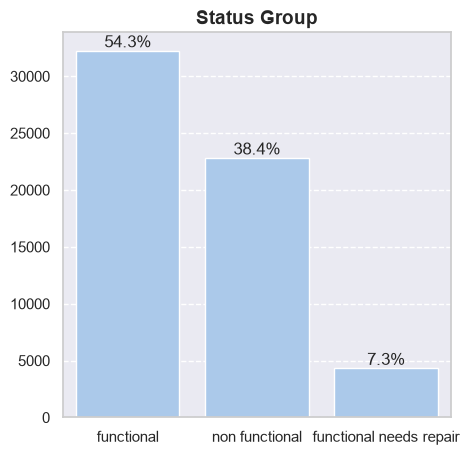

In [17]:
# Countplot de clases de la target
plt.figure(figsize=(5,5))
ax = sns.countplot(data=df, x='status_group', order=df.status_group.value_counts().index)
ax.bar_label(ax.containers[0], labels=[f'{v.get_height()/len(df):.1%}' for v in ax.containers[0]])
plt.title("Status Group", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("")
plt.show()

### Conclusiones análisis target

La variable objetivo presenta un **desbalanceo** notable entre las tres clases. La clase functional es más de la mitad de los casos mientras que functional needs repair es la clase minoritatia, representando un 7% del total aproximadamente. Este desbalance tiene varias implicaciones para las siguientes fases del proyecto:

- **Métrica de evaluación**: aunque la competición evalúa con accuracy, los datos desbalanceados pueden hacer que el accuracy sea falsamente alto. Por ello, además del accuracy, se monitorizará el F1-score y la matriz de confusión durante el desarrollo.

- **Train/test split**: al dividir los datos en train/validation o al aplicar validación cruzada, será necesario usar estratificación, de forma que cada partición mantenga la misma proporción de clases que el conjunto completo. De lo contrario, la clase minoritaria podría no quedar representada en alguna de las particiones y distorsionar la evaluación.

## Train / test split

Antes de realizar el análisis de variables y en vista de que se pretende relacionar a estas con la target para la toma de decisiones sobre su tratamiento, se debe hacer una separación de los datos en los conjuntos train y test.

Como se ha explicado antes, para no confundir con el conjunto test de la competeción, la nomenclatura para el conjunto test de la división actual será X_val e y_val en referencia a validación.

In [18]:
# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    df.drop(columns='status_group'), df['status_group'],
    test_size=0.2,
    random_state=seed,
    stratify=df['status_group']
)

display(X_train.shape, X_val.shape)

(47491, 40)

(11873, 40)

In [19]:
# Comprobar que se mantiene la proporción de clases de la target
pd.concat([
    y_train.value_counts(normalize=True).rename('Conjunto entrenamiento'),
    y_val.value_counts(normalize=True).rename('Conjunto validación')
], axis=1)

,Conjunto entrenamiento,Conjunto validación
status_group,,
functional,0.543050,0.542997
non functional,0.384283,0.384317
functional needs repair,0.072666,0.072686


In [20]:
# Renombrar el conjunto test para mayor uniformidad en la nomenclatura
X_test = test_features
X_test.shape

(14850, 40)

## Análisis de variables

**Agrupación de variables por bloques temáticos**

Dado el gran número de variables y la redundancia entre algunas de ellas, se considera conveniente hacer una agrupación de ellas en cuatros bloques temáticos para facilitar el análisis, detectar relaciones y comunicar las conclusiones de forma clara.

- **AGUA**: variables relacionadas con la disponibilidad, calidad, cantifad y tipo de captación del agua (`amount_tsh`, `water_quality`, 
  `quality_group`, `quantity`, `quantity_group`, `source`, `source_type`, `source_class`, `waterpoint_type`, `waterpoint_type_group`).

- **GESTIÓN Y MANTENIMIENTO**: variables relacionadas con quién y cómo se financia, instala, gestiona y opera el punto de agua (`scheme_management`, 
  `scheme_name`, `permit`, `management`, `management_group`, `payment`, `payment_type`, `num_private`, `funder`, `recorded_by`, `public_meeting`, `wpt_name`, `installer`, `extraction_type`, `extraction_type_group`, `extraction_type_class`).

- **GEOGRAFÍA**: variables de localización del punto de agua, tanto administrativas como geoespaciales (`longitude`, `latitude`, 
  `gps_height`, `basin`, `subvillage`, `region`, `region_code`, `district_code`, `lga`, `ward`).

- **TIEMPO Y USO**: variables relacionadas con la antigüedad y el uso del punto de agua (`date_recorded`, `construction_year`, `population`).

Esta agrupación responde a un criterio temático de negocio para mayor claridad, no a un criterio estadístico: no implica que las variables de un mismo bloque estén necesariamente correlacionadas entre sí, ni que las de bloques distintos no puedan estarlo.

No se incluye la variable 'id' ya que es el identificador de cada registro y no aporta valor predictivo.

In [21]:
water_cols = ['amount_tsh', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 
              'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group']

management_cols = ['scheme_management', 'scheme_name', 'permit', 'management', 'management_group', 
                   'payment', 'payment_type', 'num_private', 'funder', 'recorded_by', 'public_meeting',
                   'wpt_name', 'installer', 'extraction_type', 'extraction_type_group', 'extraction_type_class']

geography_cols = ['longitude', 'latitude', 'gps_height', 'basin', 'subvillage', 'region', 'region_code',
                  'district_code', 'lga', 'ward']

use_cols = ['date_recorded', 'construction_year', 'population']

Paralelamente, se van a agrupar las features tras su análisis en las siguientes categorías para una mayor efiencia a la hora del modelado.
- `num_cols`: variables numéricas
- `cat_cols`: variables categóricas
- `bin_cols`: variables binarias
- `discard_cols`: variables a descartar

In [22]:
num_cols = []
cat_cols = []
bin_cols = []
discard_cols = ['id'] # 'id' se descarta por ser un identificador único

In [23]:
# Definir función para obtener V de Cramer con el objetivo de analizar correlaciones entre categóricas y target
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

### Análisis variables de agua

In [24]:
X_train[water_cols]

,amount_tsh,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
52797,0.0,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe,communal standpipe
49162,2000.0,soft,good,seasonal,seasonal,shallow well,shallow well,groundwater,hand pump,hand pump
46439,100.0,soft,good,enough,enough,machine dbh,borehole,groundwater,other,other
55120,0.0,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
54803,0.0,coloured,colored,seasonal,seasonal,river,river/lake,surface,communal standpipe,communal standpipe
...,...,...,...,...,...,...,...,...,...,...
4589,0.0,soft,good,enough,enough,machine dbh,borehole,groundwater,hand pump,hand pump
39435,250.0,soft,good,enough,enough,river,river/lake,surface,communal standpipe multiple,communal standpipe
15857,0.0,soft,good,enough,enough,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
22190,0.0,soft,good,enough,enough,river,river/lake,surface,communal standpipe,communal standpipe


#### - `amount_tsh`

In [25]:
X_train.amount_tsh.describe()

count     47491.000000
mean        311.404531
std        2947.401950
min           0.000000
25%           0.000000
50%           0.000000
75%          20.000000
max      350000.000000
Name: amount_tsh, dtype: float64

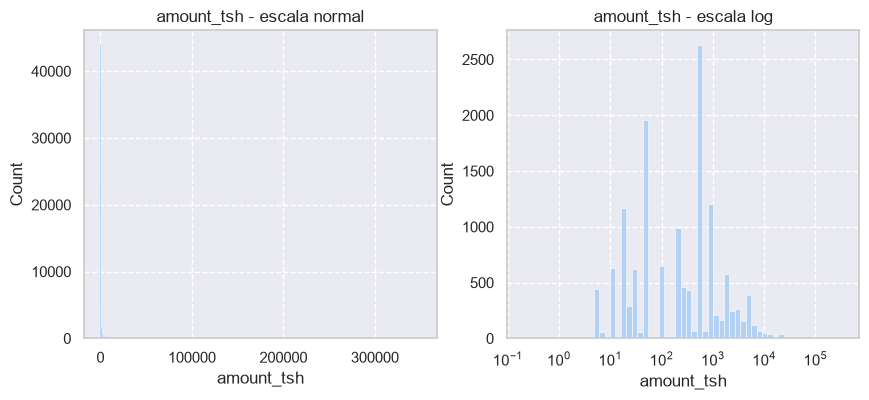

In [26]:
# Histogramas: a escala normal y a escala logarítmica (ignorando los valores igual a cero)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(X_train.amount_tsh)
plt.title("amount_tsh - escala normal")
plt.subplot(1,2,2)
sns.histplot(X_train[X_train['amount_tsh'] > 0]['amount_tsh'], log_scale=True)
plt.title("amount_tsh - escala log")
plt.show()

In [27]:
# Valores igual a cero
print("Número de valores igual a cero: ", (X_train['amount_tsh'] == 0).sum())
print("Porcentaje de valores igual a cero: ", (X_train['amount_tsh'] == 0).mean())

Número de valores igual a cero:  33305
Porcentaje de valores igual a cero:  0.7012907708829041


In [28]:
# Relación de valores igual a cero con la target
pd.crosstab(X_train['amount_tsh'] == 0, y_train, normalize='columns')

status_group,functional,functional needs repair,non functional
amount_tsh,,,
False,0.388174,0.297305,0.172548
True,0.611826,0.702695,0.827452


Conclusiones de `amount_tsh`:
- Tiene una distribución centrada en el cero, se plantea que lo más probable es que sea un missing disfrazado y no que la cantidad de agua sea igual cero.
- La proporción de ceros varía según el target, existe un incremento de proporción a medida que empeora el estado, lo que sugiere que puede tener valor predictivo a pesar del problema de ser posiblemente nulos.
- La distribución tiene un máximo de 350000, y el 75% de los datos llegan únicamente hasta 20.
  
**Decisión:** se plantea binarizar la variable, indicando si el valor es igual a cero.

#### - `water_quality` & `quality_group`

In [29]:
# Relación entre ambas variables
pd.crosstab(X_train.water_quality, X_train.quality_group)

quality_group,colored,fluoride,good,milky,salty,unknown
water_quality,,,,,,
coloured,387,0,0,0,0,0
fluoride,0,149,0,0,0,0
fluoride abandoned,0,13,0,0,0,0
milky,0,0,0,643,0,0
salty,0,0,0,0,3918,0
salty abandoned,0,0,0,0,271,0
soft,0,0,40653,0,0,0
unknown,0,0,0,0,0,1457


In [30]:
# Relación de water_quality con la target
pd.crosstab(X_train.water_quality, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
water_quality,,,
coloured,0.511628,0.098191,0.390181
fluoride,0.744966,0.073826,0.181208
fluoride abandoned,0.307692,0.000000,0.692308
milky,0.542768,0.012442,0.444790
salty,0.456100,0.047218,0.496682
salty abandoned,0.520295,0.202952,0.276753
soft,0.565616,0.076944,0.357440
unknown,0.141386,0.017845,0.840769


In [31]:
# V de Cramer: correlación entre variable y target
print("water_quality:", cramers_v(X_train.water_quality, y_train))
print("quality_group:", cramers_v(X_train.quality_group, y_train))

water_quality: 0.1366199973045307
quality_group: 0.1314491441949743


In [32]:
# Distribución de water_quality
X_train['water_quality'].value_counts(normalize=True) * 100

water_quality
soft                  85.601482
salty                  8.249984
unknown                3.067950
milky                  1.353941
coloured               0.814891
salty abandoned        0.570634
fluoride               0.313744
fluoride abandoned     0.027374
Name: proportion, dtype: float64

Conclusiones de `water_quality` & `quality_group`
- Ambas son redundantes casi al completo, teniendo 'water_quality' más categorías (diferencia entre salty y salty abandoned, así como fluoride y fluoride abandoned)
- La información que proporcionan las categorías de abandoned es importante ya que se observa un mayor porcentaje de non functional en fluoride abandoned (69%) respecto a la media de proporción de non functional (38%) de todo el dataset (aunque es cierto que es una categoría con pequeña con solamente 16 filas). También se observa que entre salty y salty abandoned hay un claro patrón distinto, obteniendo este último un porcentaje mayor en functional needs repair (20% frente a 4%).
- La V de Cramer en relación de cada variable con la target es más alta en 'water_quality'
- Unknown podría tratarse como nulo, sin embargo, es conveniente que sea una categoría más dado su comportamiento diferenciado en cuanto a la target. Imputar esta categoría podría borrar información útil y perder capacidad predictiva, además de añadir información falsa.
- Hay una alta concentración de valores de 'water_quality' en soft (85%).

**Decisión:** eliminar la variable 'quality_group' al considerarse que 'water_quality' recoge mejor la información y tener mayor valor predictivo. Se mantiene como variable categórica pero se debe tener en cuenta la concentración de los valores en 'soft' y la muestra tan reducida de 'fluoride abandoned'.

#### - `quantity` & `quantity_group`

In [33]:
# Relación entre ambas variables
pd.crosstab(X_train.quantity, X_train.quantity_group)

quantity_group,dry,enough,insufficient,seasonal,unknown
quantity,,,,,
dry,5018,0,0,0,0
enough,0,26462,0,0,0
insufficient,0,0,12101,0,0
seasonal,0,0,0,3276,0
unknown,0,0,0,0,634


In [34]:
# Relación entre quantity y la target
pd.crosstab(X_train.quantity, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
quantity,,,
dry,0.024312,0.005181,0.970506
enough,0.652785,0.073199,0.274016
insufficient,0.523593,0.094207,0.382200
seasonal,0.575702,0.103175,0.321123
unknown,0.271293,0.015773,0.712934


In [35]:
# Relación entre amount_tsh y quantity (comprobar si dry puede tener relación 
# con los valores igual a cero de amount_tsh, para descartar que sean nulos)
pd.crosstab(X_train.quantity, X_train['amount_tsh'] == 0, normalize='index')

amount_tsh,False,True
quantity,,
dry,0.116182,0.883818
enough,0.363389,0.636611
insufficient,0.280390,0.719610
seasonal,0.157814,0.842186
unknown,0.121451,0.878549


In [36]:
# Distribución de quantity
X_train['quantity'].value_counts(normalize=True) * 100

quantity
enough          55.720031
insufficient    25.480617
dry             10.566213
seasonal         6.898149
unknown          1.334990
Name: proportion, dtype: float64

Conclusiones de `quantity` & `quantity_group`
- Ambas proporcionan exactamente la misma información al observar una matriz diagonal perfecta.
- 'quantity' muestra un valor predictivo considerable al tener categorias como dry con un 97% de non functional y unknown con un 71%. Al igual que enough con un 65% de functional y las categorias intermedias (insufficient y seasonal) con proporciones superiores a la media en functional neeeds repair.
- El cruce con 'amount_tsh' confirman las sospechas de que la mayoría de valores igual a cero sean nulos ya que, aunque dry tiene la tasa más alta de ceros, enough y las demás también poseen un alto porcentaje de ceros. Hay un problema de registro de este valor más que ausencia real de agua.
- Unknown podría tratarse como nulo, sin embargo, es conveniente que sea una categoría más dado su comportamiento diferenciado en cuanto a la target..
- Hay una alta concentración de valores de 'quantity' en enough (55%) e insufficient (25%).
  
**Decisión:** eliminar quantity_group y mantener 'quantity' como categórica.

#### - `source`, `source_type` & `source_class`

In [37]:
# Comprobar cardinalidad
print("Categorías source:", X_train['source'].nunique())
print("Categorías source_type:", X_train['source_type'].nunique())
print("Categorías source_class:", X_train['source_class'].nunique())

Categorías source: 10
Categorías source_type: 7
Categorías source_class: 3


In [38]:
# Relación source y source_type
pd.crosstab(X_train.source, X_train.source_type)

source_type,borehole,dam,other,rainwater harvesting,river/lake,shallow well,spring
source,,,,,,,
dam,0,536,0,0,0,0,0
hand dtw,696,0,0,0,0,0,0
lake,0,0,0,0,617,0,0
machine dbh,8835,0,0,0,0,0,0
other,0,0,167,0,0,0,0
rainwater harvesting,0,0,0,1855,0,0,0
river,0,0,0,0,7709,0,0
shallow well,0,0,0,0,0,13393,0
spring,0,0,0,0,0,0,13621


In [39]:
# Relación source_type y source_class
pd.crosstab(X_train.source_type, X_train.source_class)

source_class,groundwater,surface,unknown
source_type,,,
borehole,9531,0,0
dam,0,536,0
other,0,0,229
rainwater harvesting,0,1855,0
river/lake,0,8326,0
shallow well,13393,0,0
spring,13621,0,0


In [40]:
# Relación source y source_class
pd.crosstab(X_train.source, X_train.source_class)

source_class,groundwater,surface,unknown
source,,,
dam,0,536,0
hand dtw,696,0,0
lake,0,617,0
machine dbh,8835,0,0
other,0,0,167
rainwater harvesting,0,1855,0
river,0,7709,0
shallow well,13393,0,0
spring,13621,0,0


In [41]:
# Relación de source con la target
pd.crosstab(X_train.source, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
source,,,
dam,0.401119,0.033582,0.565299
hand dtw,0.560345,0.020115,0.419540
lake,0.215559,0.012966,0.771475
machine dbh,0.488625,0.044822,0.466553
other,0.574850,0.005988,0.419162
rainwater harvesting,0.603235,0.135849,0.260916
river,0.567129,0.127254,0.305617
shallow well,0.493765,0.056895,0.449339
spring,0.624403,0.074517,0.301079


In [42]:
# Relación de source_type con la target
pd.crosstab(X_train.source_type, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
source_type,,,
borehole,0.493862,0.043018,0.463120
dam,0.401119,0.033582,0.565299
other,0.550218,0.021834,0.427948
rainwater harvesting,0.603235,0.135849,0.260916
river/lake,0.541076,0.118785,0.340139
shallow well,0.493765,0.056895,0.449339
spring,0.624403,0.074517,0.301079


In [43]:
# Relación de source_class con la target
pd.crosstab(X_train.source_class, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
source_class,,,
groundwater,0.542482,0.059844,0.397674
surface,0.544835,0.117477,0.337688
unknown,0.550218,0.021834,0.427948


In [44]:
# V de Cramer: correlación entre variable y target
print("source:", cramers_v(X_train.source, y_train))
print("source_type:", cramers_v(X_train.source_type, y_train))
print("source_class:", cramers_v(X_train.source_class, y_train))

source: 0.1490671683534861
source_type: 0.12721143368894244
source_class: 0.0700302919388063


In [45]:
# Distribución de source
X_train['source'].value_counts(normalize=True) * 100

source
spring                  28.681224
shallow well            28.201133
machine dbh             18.603525
river                   16.232549
rainwater harvesting     3.906003
hand dtw                 1.465541
lake                     1.299194
dam                      1.128635
other                    0.351646
unknown                  0.130551
Name: proportion, dtype: float64

Conclusiones de `source`, `source_type` & `source_class`
- Se confirma una jerarquía de las tres variables, siendo 'source' la más específica y 'source_class' la más genérica.
- 'source' muestra variación entre river (con un 30% de non functional) y lake (con un 77% de non functional), mientras que 'source_type' las agrupa en una sola categoría. Asimismo, other y unknown, que se agrupan en 'source_type', poseen proporciones distintas (57%  functional en other y 48% en unknown)
- 'source_class' no parece tener poder discriminatorio al presentar proporciones similares en las tres categorías. Aunque surface puede dar información sobre functional needs repair, esta información ya viene recogida en source, por lo que es redundante.
- La V de Cramer de la correlación entre las tres variables y la target confirma que 'source' tiene más podeer discriminatorio, aunque es cierto que la cardinalidad pueda estar aumentado el estadístico respecto al resto.
- Unknown podría tratarse como nulo, sin embargo, es conveniente que sea una categoría más dado su comportamiento diferenciado en cuanto a la target. 
- Hay una alta concentración de valores de 'source' en spring (28%), shallow well (28%), machine dbh (18%) y river (16%).
  
**Decisión:** eliminar 'source_type' y 'source_class' y mantener 'source' como variable categórica dado que tiene mayor valor predictivo. 

#### - `waterpoint_type ` & `waterpoint_type_group`

In [46]:
# Relación waterpoint_type y waterpoint_type_group
pd.crosstab(X_train.waterpoint_type, X_train.waterpoint_type_group)

waterpoint_type_group,cattle trough,communal standpipe,dam,hand pump,improved spring,other
waterpoint_type,,,,,,
cattle trough,94,0,0,0,0,0
communal standpipe,0,22857,0,0,0,0
communal standpipe multiple,0,4900,0,0,0,0
dam,0,0,6,0,0,0
hand pump,0,0,0,13908,0,0
improved spring,0,0,0,0,644,0
other,0,0,0,0,0,5082


In [47]:
# Relación de waterpoint_type con la target
pd.crosstab(X_train.waterpoint_type, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
waterpoint_type,,,
cattle trough,0.723404,0.021277,0.255319
communal standpipe,0.621035,0.080107,0.298858
communal standpipe multiple,0.367959,0.102653,0.529388
dam,0.833333,0.000000,0.166667
hand pump,0.618062,0.058743,0.323195
improved spring,0.726708,0.102484,0.170807
other,0.128886,0.045651,0.825462


In [48]:
# Relación de waterpoint_type_group con la target
pd.crosstab(X_train.waterpoint_type_group, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
waterpoint_type_group,,,
cattle trough,0.723404,0.021277,0.255319
communal standpipe,0.576359,0.084087,0.339554
dam,0.833333,0.000000,0.166667
hand pump,0.618062,0.058743,0.323195
improved spring,0.726708,0.102484,0.170807
other,0.128886,0.045651,0.825462


In [49]:
# V de Cramer: correlación entre variable y target
print("waterpoint_type:", cramers_v(X_train.waterpoint_type, y_train))
print("waterpoint_type_group:", cramers_v(X_train.waterpoint_type_group, y_train))

waterpoint_type: 0.25131971124175256
waterpoint_type_group: 0.2279894379496736


In [50]:
# Distribución de waterpoint_type
X_train['waterpoint_type'].value_counts(normalize=True) * 100

waterpoint_type
communal standpipe             48.129119
hand pump                      29.285549
other                          10.700975
communal standpipe multiple    10.317744
improved spring                 1.356046
cattle trough                   0.197932
dam                             0.012634
Name: proportion, dtype: float64

Conclusiones de `waterpoint_type` & `waterpoint_type_group`

- Ambas variables proporcionan la misma información, pero waterpoint_type es más específica ya que separa entre communal standpipe y communal standpipe multiple, mientras que waterpoint_type_group los agrupa en uno solo. 
- Hay un patrón diferenciado entre communal standpipe y communal standpipe multiple, por lo que agruparlas provoca pérdida de información, resultando 'waterpoint_type' una variable más valiosa para el modelo predictivo. Además, la V de Cramer en relación con la target es mayor en 'waterpoint_type'.
- La categoría dam tiene únicamente 6 registros.
  
**Decisión:** eliminar 'waterpoint_type_group' dado que 'waterpoint_type' aporta más información predictiva. Se mantiene esta última como variable categórica y se debe tener en cuenta la categoría dam en decisiones de modelado o preprocesamiento.

#### Clasificar variables

In [51]:
# Clasificar water_cols en cat_cols, num_cols, bin_cols y discard_cols
num_cols.append('amount_tsh')
cat_cols.extend(['water_quality', 'quantity', 'source', 'waterpoint_type'])
discard_cols.extend(['quality_group', 'quantity_group', 'source_type', 'source_class', 'waterpoint_type_group'])

### Análisis variables de gestión y mantenimiento

In [52]:
X_train[management_cols]

,scheme_management,scheme_name,permit,management,management_group,payment,payment_type,num_private,funder,recorded_by,public_meeting,wpt_name,installer,extraction_type,extraction_type_group,extraction_type_class
52797,VWC,Kazaroho water supply,True,vwc,user-group,never pay,never pay,0,Government Of Tanzania,GeoData Consultants Ltd,True,Shuleni,Cental Government,ksb,submersible,submersible
49162,VWC,NaN,True,vwc,user-group,pay when scheme fails,on failure,0,Danida,GeoData Consultants Ltd,True,Kwa Andrea,DWE,india mark ii,india mark ii,handpump
46439,NaN,NaN,True,vwc,user-group,pay per bucket,per bucket,0,Buluga Subvillage Community,GeoData Consultants Ltd,True,Kwa Langidare,DWE,submersible,submersible,submersible
55120,VWC,Nabaiye pipe line,True,vwc,user-group,never pay,never pay,0,Oxfam,GeoData Consultants Ltd,True,Kwa Karani Lekamoi,DWE,gravity,gravity,gravity
54803,Water Board,NaN,True,water board,user-group,never pay,never pay,0,NaN,GeoData Consultants Ltd,False,Kwa Mtamo,NaN,gravity,gravity,gravity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4589,Water authority,NaN,True,water authority,commercial,never pay,never pay,0,Tcrs,GeoData Consultants Ltd,True,Plot 40,TCRS,other,other,other
39435,Water authority,Kigondo,True,water board,user-group,pay monthly,monthly,0,Danida,GeoData Consultants Ltd,True,Sokoni,DANIDA,gravity,gravity,gravity
15857,VWC,NaN,True,vwc,user-group,never pay,never pay,0,Brdp,GeoData Consultants Ltd,True,Farmers Extension Center,RUNDAGA,gravity,gravity,gravity
22190,VWC,Mazinde water supply,False,vwc,user-group,never pay,never pay,0,Village Government,GeoData Consultants Ltd,True,Uhindini,Local technician,gravity,gravity,gravity


#### - `scheme_management` & `scheme_name`

In [53]:
# Distribución de scheme_management
display(pd.DataFrame({
    'conteo': X_train['scheme_management'].value_counts(normalize=False),
    'porcentaje': X_train['scheme_management'].value_counts(normalize=True)
}))

,conteo,porcentaje
scheme_management,,
VWC,29419,0.662948
WUG,4172,0.094015
Water authority,2551,0.057486
WUA,2297,0.051762
Water Board,2170,0.048900
Parastatal,1322,0.029791
Private operator,852,0.019200
Company,846,0.019064
Other,609,0.013724


In [54]:
# Distribución de scheme_name
display(pd.DataFrame({
    'conteo': X_train['scheme_name'].value_counts(normalize=False),
    'porcentaje': X_train['scheme_name'].value_counts(normalize=True)
}))

,conteo,porcentaje
scheme_name,,
K,564,0.023060
Borehole,426,0.017418
M,319,0.013043
DANIDA,317,0.012961
Chalinze wate,309,0.012634
...,...,...
Kaseni water supply,1,0.000041
Mradi wa Maji sekondari kizigo,1,0.000041
Mwarusembe Water Supply,1,0.000041


In [55]:
# Nulos de scheme_management
X_train.scheme_management.isna().sum()

np.int64(3115)

In [56]:
# Nulos de scheme_name
X_train.scheme_name.isna().sum()

np.int64(23033)

In [57]:
# Relación de nulos de scheme_management con la target
pd.crosstab(X_train.scheme_management.isna(), y_train, normalize='index')

status_group,functional,functional needs repair,non functional
scheme_management,,,
False,0.546895,0.073936,0.379169
True,0.488283,0.054575,0.457143


In [58]:
# Relación de scheme_management con la target
pd.crosstab(X_train.scheme_management, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
scheme_management,,,
Company,0.500000,0.040189,0.459811
Other,0.591133,0.024631,0.384236
Parastatal,0.568835,0.123298,0.307867
Private operator,0.684272,0.022300,0.293427
SWC,0.182927,0.012195,0.804878
Trust,0.642857,0.071429,0.285714
VWC,0.515517,0.063292,0.421190
WUA,0.687854,0.085329,0.226818
WUG,0.574305,0.129674,0.296021


Conclusiones de `scheme_management` & `scheme_name`

- Hay una alta concentración de los valores de 'scheme_management' en VWC (66% de los datos)
- Hay 3115 nulos en scheme_management y presentan un porcentaje de non functional superior a la media.
- 'scheme_name' tiene una cardinalidad alta con 2532 categorías únicas, siendo K la más frecuente y con un 2% de los datos. Se trata de numerosos nombres que hacen la variable prácticamente imposible de tratar con encoding. Además, tiene 23033 nulos, representando casi la mitad del dataset.
  
**Decisión:** eliminar 'scheme_name' por la cardinalidad, número de nulos y señal de no poder validar con confianza por el tamaño de la muestra de cada categoría (menor al 3%). Se conserva 'scheme_management' como variable categórica y queda pendiente el tratamiento de nulos, además de tener en cuenta la concentración de valores en VWC.

#### - `permit` & `public_meeting`

In [59]:
# Distribución de permit
X_train.permit.value_counts(normalize=True, dropna=False)

permit
True     0.653029
False    0.295024
NaN      0.051947
Name: proportion, dtype: float64

In [60]:
# Relación de permit con la target
pd.crosstab(X_train.permit, y_train, normalize='index', dropna=False)

status_group,functional,functional needs repair,non functional
permit,,,
True,0.554574,0.069487,0.375939
NaN,0.541548,0.096473,0.361978
False,0.517807,0.075512,0.406680


In [61]:
# Distribución de public_meeting
X_train.public_meeting.value_counts(normalize=True, dropna=False)

public_meeting
True     0.858626
False    0.085027
NaN      0.056348
Name: proportion, dtype: float64

In [62]:
# Relación de public_meeting con la target
pd.crosstab(X_train.public_meeting, y_train, normalize='index', dropna=False)

status_group,functional,functional needs repair,non functional
public_meeting,,,
False,0.429668,0.085686,0.484646
True,0.557349,0.072982,0.369669
NaN,0.496263,0.048206,0.455531


In [63]:
# V de Cramer: correlación entre variables (con y sin nulos) y target
permit_with_nan = X_train['permit'].fillna('missing').astype(str)
print("permit_with_nan:", cramers_v(permit_with_nan, y_train))

permit_without_nan = X_train['permit'].notna()
print("permit_without_nan:", cramers_v(X_train.loc[permit_without_nan, 'permit'], y_train.loc[permit_without_nan]))

public_meeting_with_nan = X_train['public_meeting'].fillna('missing').astype(str)
print("\npublic_meeting_with_nan:", cramers_v(public_meeting_with_nan, y_train))

public_meeting_without_nan = X_train['public_meeting'].notna()
print("public_meeting_without_nan:", cramers_v(X_train.loc[public_meeting_without_nan, 'public_meeting'], y_train.loc[public_meeting_without_nan]))

permit_with_nan: 0.028334198343904587
permit_without_nan: 0.03417580871151814

public_meeting_with_nan: 0.057779101567595366
public_meeting_without_nan: 0.07402022294381375


Conclusiones de `permit` & `public_meeting`

- 'permit' muestra poca variación respecto a la target, mientras que 'public_meeting' tiene más poder discriminatorio (False con un 48% de non functional y True con un 37%).
- En ambos casos, los valores nulos no muestran un comportamiento extremo. Para valorar si el valor nulo aporta señal propia, se calculó la V de Cramer de cada variable frente al target, tanto tratando los nulos como categoría explícita como excluyéndolo. En ambos casos, la asociación con la target es débil (V < 0.1), y tratar los nulos como categoría propia no incrementa la asociación global, sino que la reduce ligeramente.

  
**Decisión:** se conservan ambas variables como binarias, quedando pendiente la imputación de los nulos.

#### - `management` & `management_group`

In [64]:
# Relación entre ambas variables
pd.crosstab(X_train.management, X_train.management_group)

management_group,commercial,other,parastatal,unknown,user-group
management,,,,,
company,545,0,0,0,0
other,0,681,0,0,0
other - school,0,84,0,0,0
parastatal,0,0,1383,0,0
private operator,1585,0,0,0,0
trust,62,0,0,0,0
unknown,0,0,0,454,0
vwc,0,0,0,0,32397
water authority,736,0,0,0,0


In [65]:
# Relación entre management con la target
pd.crosstab(X_train.management, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
management,,,
company,0.394495,0.023853,0.581651
other,0.609398,0.057269,0.333333
other - school,0.214286,0.011905,0.773810
parastatal,0.568330,0.123644,0.308026
private operator,0.752681,0.020820,0.226498
trust,0.580645,0.080645,0.338710
unknown,0.392070,0.050661,0.557269
vwc,0.504923,0.068648,0.426428
water authority,0.490489,0.054348,0.455163


In [66]:
# V de Cramer: correlación entre variable y target
print("management:", cramers_v(X_train.management, y_train))
print("management_group:", cramers_v(X_train.management_group, y_train))

management: 0.13333973590513443
management_group: 0.050854289979407614


In [67]:
# Distribución de management
X_train.management.value_counts(normalize=True)

management
vwc                 0.682171
wug                 0.109747
water board         0.049209
wua                 0.042429
private operator    0.033375
parastatal          0.029121
water authority     0.015498
other               0.014340
company             0.011476
unknown             0.009560
other - school      0.001769
trust               0.001306
Name: proportion, dtype: float64

In [68]:
# Relación entre scheme_management y management
pd.crosstab(X_train.scheme_management, X_train.management)

management,company,other,other - school,parastatal,private operator,trust,unknown,vwc,water authority,water board,wua,wug
scheme_management,,,,,,,,,,,,
Company,535,2,0,16,179,0,0,113,0,0,0,1
Other,0,416,0,1,51,1,6,27,16,0,0,91
Parastatal,0,0,0,1226,54,0,3,37,1,1,0,0
Private operator,2,2,0,2,770,1,0,71,3,0,0,1
SWC,0,0,74,0,0,0,0,7,0,0,0,1
Trust,1,0,0,1,1,46,0,5,1,1,0,0
VWC,1,38,10,100,133,2,63,28294,7,31,84,656
WUA,1,1,0,22,151,0,1,188,0,0,1894,39
WUG,4,10,0,5,5,0,4,321,0,0,0,3823


In [69]:
# Relación scheme_management con la target
pd.crosstab(X_train.scheme_management, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
scheme_management,,,
Company,0.500000,0.040189,0.459811
Other,0.591133,0.024631,0.384236
Parastatal,0.568835,0.123298,0.307867
Private operator,0.684272,0.022300,0.293427
SWC,0.182927,0.012195,0.804878
Trust,0.642857,0.071429,0.285714
VWC,0.515517,0.063292,0.421190
WUA,0.687854,0.085329,0.226818
WUG,0.574305,0.129674,0.296021


Conclusiones de `management` & `management_group`

- Ambas variables proporcionan la misma información, pero 'management' es más específica.
- Hay un variación con la target entre las categorías de 'management' que 'management_group' agrupa en una sola (por ejemplo other y other school, con un 60% y 21% de functional respectivamente).
- La V de Cramer confirma que 'management' tiene mayor poder discriminatorio (0,13 frente a 0,05 de 'management_group')
- Hay una concentración de valores de management en vwc, con un 68% de los datos pertenecientes a esta categoría.
- Aunque comparten valores, no resultan redundantes ya que se observa que categorías con nombres equivalentes presentan tasas de target distintas entre ambas variables (por ejemplo, company de 'scheme_management' con un 46% de non functional y en 'management' un 58%). 
  
**Decisión:** eliminar 'management_group' dado que 'management' aporta más información predictiva. Se mantiene esta última como variable categórica y se debe tener en cuenta la concentración de los datos en vwc. Se plantea crear una variable booleana que indique si el valor de 'management' coincide con 'scheme_management'

#### - `payment` & `payment_type`

In [70]:
# Relación entre payment y payment_type
pd.crosstab(X_train.payment, X_train.payment_type)

payment_type,annually,monthly,never pay,on failure,other,per bucket,unknown
payment,,,,,,,
never pay,0,0,20254,0,0,0,0
other,0,0,0,0,830,0,0
pay annually,2878,0,0,0,0,0,0
pay monthly,0,6666,0,0,0,0,0
pay per bucket,0,0,0,0,0,7186,0
pay when scheme fails,0,0,0,3140,0,0,0
unknown,0,0,0,0,0,0,6537


In [71]:
# Distribución de payment
X_train.payment.value_counts(normalize=True)

payment
never pay                0.426481
pay per bucket           0.151313
pay monthly              0.140363
unknown                  0.137647
pay when scheme fails    0.066118
pay annually             0.060601
other                    0.017477
Name: proportion, dtype: float64

In [72]:
# Relación de payment con la target
pd.crosstab(X_train.payment, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
payment,,,
never pay,0.447961,0.074800,0.477239
other,0.581928,0.112048,0.306024
pay annually,0.751564,0.067060,0.181376
pay monthly,0.661566,0.113111,0.225323
pay per bucket,0.675341,0.046340,0.278319
pay when scheme fails,0.629618,0.068790,0.301592
unknown,0.433073,0.053082,0.513844


Conclusiones de `payment` & `payment_type`

- Son variables idénticas, mismas categorías y distribución.
- never pay es la categoría dominante, con un 42%, y le siguen porcentajes menores a 16%.
- Las categorías de pago activo son notablemente más funcionales mientras que never pay, unknown u other tienen más porcentaje de non functional.
- La categoría unknown muestra la peor tasa de non functional, reforzando el patrón ya observado en otras variables de que el desconocimiento proporciona información y no es aleatorio.
  
**Decisión:** eliminar payment_type, conservando 'payment' como variable categórica.

#### - `num_private`

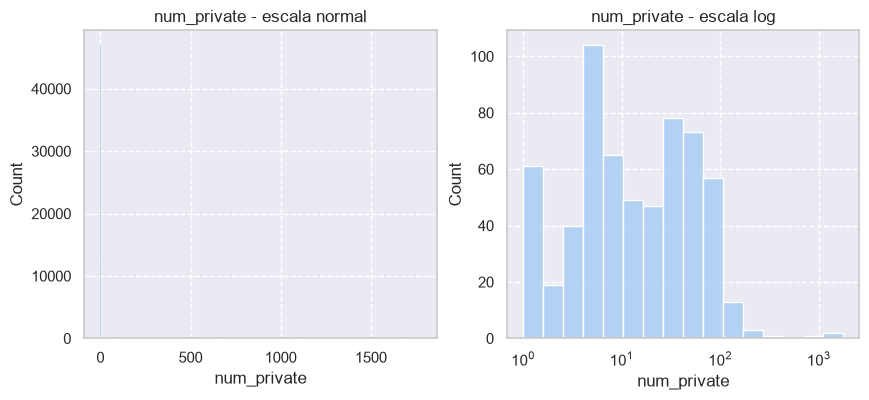

In [73]:
# Histogramas: a escala normal y a escala logarítmica (ignorando los valores igual a cero)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(X_train.num_private)
plt.title("num_private - escala normal")
plt.subplot(1,2,2)
sns.histplot(X_train[X_train['num_private'] > 0]['num_private'], log_scale=True)
plt.title("num_private - escala log")
plt.show()

In [74]:
# Número y porcentaje de valores igual a cero
print("Número de valores igual a cero: ", (X_train['num_private'] == 0).sum())
print("Porcentaje de valores igual a cero: ", (X_train['num_private'] == 0).mean())

Número de valores igual a cero:  46878
Porcentaje de valores igual a cero:  0.9870922911709588


In [75]:
# Relación de la variable con la target cuando el valor es igual a cero
pd.crosstab(X_train['num_private'] == 0, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
num_private,,,
False,0.603589,0.065253,0.331158
True,0.542259,0.072763,0.384978


Conclusiones de `num_private`

- El 98% de valores son 0, la varianza es casi nula.
- Se plantea binarizar la varuable (igual o desigual a 0). Al observar la relación con la target, los valores distintos a cero tienen una mayor proporción de functional (60% frente a 54%) y menos non functional (33% frente a 38%). Sin embargo, la diferencia no es extrema y dado el tamaño de la muestra puede haber riesgo de sobreajuste.
  
**Decisión:** eliminar 'num_private'.

#### - `funder`

In [76]:
# Cardinalidad de funder
X_train.funder.nunique()

1680

In [77]:
# Nulos de funder
X_train.funder.isna().sum()

np.int64(2940)

In [78]:
# Distribución de funder
X_train.funder.value_counts(normalize=True).head(30)

funder
Government Of Tanzania    0.164171
Danida                    0.056677
Hesawa                    0.039528
Rwssp                     0.024803
World Bank                0.023995
Kkkt                      0.022850
World Vision              0.022109
Unicef                    0.018608
Tasaf                     0.015937
District Council          0.015353
Private Individual        0.014904
Dhv                       0.014612
Dwsp                      0.014523
0                         0.013917
Norad                     0.013872
Tcrs                      0.010752
Ministry Of Water         0.010729
Germany Republi           0.010639
Water                     0.010527
Netherlands               0.008462
Dwe                       0.008395
Lga                       0.008170
Hifab                     0.007879
Adb                       0.007766
Amref                     0.007564
Fini Water                0.007183
Oxfam                     0.006442
Wateraid                  0.005948
Isf          

In [79]:
# Valores igual a 0
(X_train['funder']=='0').sum()

np.int64(620)

In [80]:
# Relación de la categoría Government of Tanzania con la target
pd.crosstab(X_train['funder']=="Government Of Tanzania", y_train, normalize='index')

status_group,functional,functional needs repair,non functional
funder,,,
False,0.567066,0.071882,0.361052
True,0.411129,0.076976,0.511895


In [81]:
# Relación de nulos con la target
pd.crosstab(X_train['funder'].isna(), y_train, normalize='index')

status_group,functional,functional needs repair,non functional
funder,,,
False,0.542839,0.069493,0.387668
True,0.546259,0.120748,0.332993


In [82]:
# Relación de la categoría igual a 0 con la target
pd.crosstab(X_train['funder'] == '0', y_train, normalize='index')

status_group,functional,functional needs repair,non functional
funder,,,
False,0.542766,0.073564,0.383670
True,0.564516,0.004839,0.430645


In [83]:
# Relación de top categorías con la target
top_funders = X_train.funder.value_counts().head(10).index
pd.crosstab(X_train[X_train.funder.isin(top_funders)]['funder'], y_train, normalize='index')

status_group,functional,functional needs repair,non functional
funder,,,
Danida,0.551683,0.051485,0.396832
District Council,0.435673,0.057018,0.507310
Government Of Tanzania,0.411129,0.076976,0.511895
Hesawa,0.420216,0.099943,0.479841
Kkkt,0.569745,0.048134,0.382122
Rwssp,0.580995,0.085068,0.333937
Tasaf,0.563380,0.078873,0.357746
Unicef,0.562123,0.100121,0.337756
World Bank,0.418148,0.070159,0.511693


Conclusiones de `funder`

- Tiene una alta cardinalidad, con 1680 categorías.
- Government of Tanzania tiene el 16% de los datos, y el resto se distribuye en las demás categorías.
- Hay 2955 nulos y 620 valores igual a cero (nulo disfrazado).
- Los valores igual a 0 presentan un porcentaje muy bajo de functional needs repair, mientras que los valores nulos tienen un 12%, por lo que unificarlos puede llevar a pérdida de información. 

  
**Decisión:** se conserva 'funder' como variable categórica, pendiente del tratamiento de nulos y de la alta cardinalidad (se plantea mantener un Top N de categorías y agrupar el resto en otros). Los nulos reales y los valores 0 se tratarán como dos categorías missing separadas dado que muestran comportamientos distintos frente a la target.

#### - `recorded_by`

**Decisión:** eliminar 'recorded_by' ya que anteriormente se comprobó que tenía una sola categoría, no aportando ninguna información

#### - `wpt_name`

In [84]:
# Cardinalidad de wpt_name
X_train.wpt_name.nunique()

30711

In [85]:
# Nulos de wpt_name
X_train.wpt_name.isna().sum()

np.int64(1)

In [86]:
# Distribución de wpt_name
X_train.wpt_name.value_counts(normalize=True).head(30)

wpt_name
none               0.059992
Shuleni            0.029396
Zahanati           0.014129
Msikitini          0.009160
Kanisani           0.005412
Bombani            0.004548
Sokoni             0.004359
Ofisini            0.004211
School             0.003559
Shule Ya Msingi    0.003348
Shule              0.002611
Sekondari          0.002337
Muungano           0.002148
Madukani           0.001706
Upendo             0.001642
Kituo Cha Afya     0.001621
Mkombozi           0.001579
Mbugani            0.001516
Center             0.001453
Hospital           0.001432
Kisimani           0.001327
Mtakuja            0.001327
Mkuyuni            0.001327
Umoja              0.001306
Ofisi Ya Kijiji    0.001242
Bwawani            0.001179
Bondeni            0.001116
Tankini            0.001095
Songambele         0.001053
Ccm                0.001053
Name: proportion, dtype: float64

In [87]:
# Relación de categoría none con la target
pd.crosstab(X_train['wpt_name'] == 'none', y_train, normalize='index')

status_group,functional,functional needs repair,non functional
wpt_name,,,
False,0.530577,0.075982,0.393441
True,0.738505,0.020709,0.240786


Conclusiones de `wpt_name`

- Tiene una cardinalidad altísima, con 30737 categorías o prácticamente un 65% del dataset con nombres únicos. La categoría más frecuente es none y no llega al 6% de los datos.

  
**Decisión:** se elimina 'wpt_name' por ausencia de categorías generalizables con volumen suficiente para aportar una señal fiable.

#### - `installer`

In [88]:
# Cardinalidad de installer
X_train.installer.nunique()

1930

In [89]:
# Nulos de installer
X_train.installer.isna().sum()

np.int64(2955)

In [90]:
# Distribución de installer
X_train.installer.value_counts(normalize=True).head(10)

installer
DWE                   0.310782
Government            0.032940
RWE                   0.022184
DANIDA                0.019288
Commu                 0.019108
KKKT                  0.015763
Hesawa                0.014954
0                     0.013921
TCRS                  0.012844
Central government    0.011631
Name: proportion, dtype: float64

In [91]:
# Valores igual a 0
(X_train['installer'] == '0').sum()

np.int64(620)

In [92]:
# Relación de top categorías con la target
top_installers = X_train['installer'].value_counts().head(10).index
pd.crosstab(X_train[X_train['installer'].isin(top_installers)]['installer'], y_train, normalize='index')

status_group,functional,functional needs repair,non functional
installer,,,
0,0.564516,0.004839,0.430645
Central government,0.266409,0.007722,0.725869
Commu,0.686251,0.024677,0.289072
DANIDA,0.522701,0.081490,0.395809
DWE,0.544325,0.092334,0.363341
Government,0.292434,0.143149,0.564417
Hesawa,0.543544,0.018018,0.438438
KKKT,0.482906,0.066952,0.450142
RWE,0.250000,0.114372,0.635628


In [93]:
# Relación de nulos con la target
pd.crosstab(X_train['installer'].isna(), y_train, normalize='index')

status_group,functional,functional needs repair,non functional
installer,,,
False,0.542729,0.069472,0.387799
True,0.547885,0.120812,0.331303


In [94]:
# Relación entre valores igual a 0 en 'funder' e 'installer'
(X_train.loc[X_train['funder'] == '0', 'id'].values == X_train.loc[X_train['installer'] == '0', 'id'].values).all() if (X_train['funder']=='0').sum() == (X_train['installer']=='0').sum() else "distintos"

np.True_

Conclusiones de `installer`

- Tiene una alta cardinalidad, con 1912 categorías.
- Hay 2955 nulos y 620 valores igual a 0, coincidiendo con aquellos valores igual a 0 de 'funder'. 
- Se observa variabilidad con la target en las categorías más frecuentes.
  
**Decisión:** se conserva 'installer' y se realiza la misma estrategia que en 'funder', conservar un top N de categoría y agrupar el resto en otros, dejando los nulos y los valores igual a 0 en categorías distintas.

#### - `extraction_type`, `extraction_type_group` & `extraction_type_class`

In [95]:
# Cardinalidad de las variables
print("Categorías extraction_type:", X_train['extraction_type'].nunique())
print("Categorías extraction_type_group:", X_train['extraction_type_group'].nunique())
print("Categorías extraction_type_class:", X_train['extraction_type_class'].nunique())

Categorías extraction_type: 18
Categorías extraction_type_group: 13
Categorías extraction_type_class: 7


In [96]:
# V de Cramer: correlación entre variable y target
print("extraction_type:", cramers_v(X_train.extraction_type, y_train))
print("extraction_type_group:", cramers_v(X_train.extraction_type_group, y_train))
print("extraction_type_class:", cramers_v(X_train.extraction_type_class, y_train))

extraction_type: 0.24824081720943336
extraction_type_group: 0.2464072257244595
extraction_type_class: 0.24070157847909623


In [97]:
# Relación entre extraction_type y extraction_type_group
pd.crosstab(X_train.extraction_type, X_train.extraction_type_group)

extraction_type_group,afridev,gravity,india mark ii,india mark iii,mono,nira/tanira,other,other handpump,other motorpump,rope pump,submersible,swn 80,wind-powered
extraction_type,,,,,,,,,,,,,
afridev,1419,0,0,0,0,0,0,0,0,0,0,0,0
cemo,0,0,0,0,0,0,0,0,72,0,0,0,0
climax,0,0,0,0,0,0,0,0,24,0,0,0,0
gravity,0,21491,0,0,0,0,0,0,0,0,0,0,0
india mark ii,0,0,1944,0,0,0,0,0,0,0,0,0,0
india mark iii,0,0,0,73,0,0,0,0,0,0,0,0,0
ksb,0,0,0,0,0,0,0,0,0,0,1101,0,0
mono,0,0,0,0,2303,0,0,0,0,0,0,0,0
nira/tanira,0,0,0,0,0,6476,0,0,0,0,0,0,0


In [98]:
# Relación entre extraction_type y extraction_type_class
pd.crosstab(X_train.extraction_type, X_train.extraction_type_class)

extraction_type_class,gravity,handpump,motorpump,other,rope pump,submersible,wind-powered
extraction_type,,,,,,,
afridev,0,1419,0,0,0,0,0
cemo,0,0,72,0,0,0,0
climax,0,0,24,0,0,0,0
gravity,21491,0,0,0,0,0,0
india mark ii,0,1944,0,0,0,0,0
india mark iii,0,73,0,0,0,0,0
ksb,0,0,0,0,0,1101,0
mono,0,0,2303,0,0,0,0
nira/tanira,0,6476,0,0,0,0,0


In [99]:
# Relación entre extraction_type_group y extraction_type_class
pd.crosstab(X_train.extraction_type_group, X_train.extraction_type_class)

extraction_type_class,gravity,handpump,motorpump,other,rope pump,submersible,wind-powered
extraction_type_group,,,,,,,
afridev,0,1419,0,0,0,0,0
gravity,21491,0,0,0,0,0,0
india mark ii,0,1944,0,0,0,0,0
india mark iii,0,73,0,0,0,0,0
mono,0,0,2303,0,0,0,0
nira/tanira,0,6476,0,0,0,0,0
other,0,0,0,5138,0,0,0
other handpump,0,288,0,0,0,0,0
other motorpump,0,0,96,0,0,0,0


In [100]:
# Relación entre extraction_type y la target
pd.crosstab(X_train.extraction_type, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
extraction_type,,,
afridev,0.673009,0.026075,0.300916
cemo,0.555556,0.097222,0.347222
climax,0.208333,0.000000,0.791667
gravity,0.599228,0.100693,0.300079
india mark ii,0.602881,0.034465,0.362654
india mark iii,0.465753,0.013699,0.520548
ksb,0.495913,0.018165,0.485922
mono,0.379505,0.046027,0.574468
nira/tanira,0.665689,0.079061,0.255250


In [101]:
# Relación entre extraction_type_group y la target
pd.crosstab(X_train.extraction_type_group, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
extraction_type_group,,,
afridev,0.673009,0.026075,0.300916
gravity,0.599228,0.100693,0.300079
india mark ii,0.602881,0.034465,0.362654
india mark iii,0.465753,0.013699,0.520548
mono,0.379505,0.046027,0.574468
nira/tanira,0.665689,0.079061,0.255250
other,0.161347,0.031530,0.807123
other handpump,0.482639,0.059028,0.458333
other motorpump,0.468750,0.072917,0.458333


In [102]:
# Relación entre extraction_type_class y la target
pd.crosstab(X_train.extraction_type_class, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
extraction_type_class,,,
gravity,0.599228,0.100693,0.300079
handpump,0.630720,0.060021,0.309259
motorpump,0.383076,0.047103,0.569821
other,0.161347,0.031530,0.807123
rope pump,0.643678,0.040230,0.316092
submersible,0.535423,0.041938,0.422638
wind-powered,0.439560,0.054945,0.505495


In [103]:
# Distribución de extraction_type
X_train.extraction_type.value_counts()

extraction_type
gravity                      21491
nira/tanira                   6476
other                         5138
submersible                   3811
swn 80                        2912
mono                          2303
india mark ii                 1944
afridev                       1419
ksb                           1101
other - rope pump              348
other - swn 81                 182
windmill                        91
india mark iii                  73
cemo                            72
other - play pump               64
walimi                          41
climax                          24
other - mkulima/shinyanga        1
Name: count, dtype: int64

In [104]:
# Distribución de extraction_type_group
X_train.extraction_type_group.value_counts()

extraction_type_group
gravity            21491
nira/tanira         6476
other               5138
submersible         4912
swn 80              2912
mono                2303
india mark ii       1944
afridev             1419
rope pump            348
other handpump       288
other motorpump       96
wind-powered          91
india mark iii        73
Name: count, dtype: int64

In [105]:
# Distribución de extraction_type_class
X_train.extraction_type_class.value_counts()

extraction_type_class
gravity         21491
handpump        13112
other            5138
submersible      4912
motorpump        2399
rope pump         348
wind-powered       91
Name: count, dtype: int64

Conclusiones de `extraction_type`, `extraction_type_group` & `extraction_type_class`
- Se confirma una jerarquía de las tres variables, siendo 'extraction_type' la más específica y 'extraction_type_class' la más genérica.
- La V de Cramer de la correlación entre las tres variables y la target confirma que 'extraction_type' tiene más podeer discriminatorio, aunque se puede deber a una mayor cardinalidad.
- 'extraction_type_class' agrupa cemo, climax y mono en motorpump, pero estas tienen patrones distintos e incluso contrarios frente a la target. Aunque hay que tener en cuenta que las muestras son reducidas. La categoría handpump agrupa varias categorías que también tienen proprociones distintas, lo que puede dar lugar a una pérdida de información.
- Hay una alta concentración de valores de 'extraction_type' en gravity (45%), nira/tanira (13%) y other (10%).
  
**Decisión:** eliminar 'extraction_type_group' y 'extraction_type_class' dado que 'extraction_type' aporta más información predictiva al preservar matices que los niveles agregados pierden. Esta última se mantiene como categórica, pendiente de tratar aquellas categorías con muestras reducidas.

#### Clasificar variables

In [106]:
# Clasificar management_cols en cat_cols, num_cols, bin_cols y discard_cols
cat_cols.extend(['scheme_management', 'management', 'payment', 'funder', 'installer', 'extraction_type'])
bin_cols.extend(['permit', 'public_meeting'])
discard_cols.extend(['scheme_name', 'management_group', 'payment_type', 'num_private', 'recorded_by', 
                     'wpt_name', 'extraction_type_group', 'extraction_type_class'])

### Análisis variables de geografía

In [107]:
X_train[geography_cols]

,longitude,latitude,gps_height,basin,subvillage,region,region_code,district_code,lga,ward
52797,31.854941,-4.985824,0,Lake Tanganyika,Kazaroho Mashariki,Tabora,14,4,Urambo,Kazaroho
49162,35.413765,-10.584022,962,Ruvuma / Southern Coast,Raha Leo B,Ruvuma,10,2,Songea Rural,Maposeni
46439,36.841180,-3.542596,954,Pangani,Buluga,Arusha,2,2,Arusha Rural,Bwawani
55120,36.696317,-3.318182,1668,Pangani,Oleiguruno,Arusha,2,2,Arusha Rural,Ilkiding'a
54803,34.377395,-8.694945,0,Rufiji,Isisi,Mbeya,12,7,Mbarali,Rujewa
...,...,...,...,...,...,...,...,...,...,...
4589,30.329597,-5.544649,1134,Lake Tanganyika,Barabara 3,Rukwa,15,1,Mpanda,Mishamo
39435,30.064750,-4.318107,1379,Lake Tanganyika,Madukani,Kigoma,16,2,Kasulu,Munyegera
15857,31.496020,-1.565303,0,Lake Victoria,Kabirizi Mangaribi,Kagera,18,2,Bukoba Rural,Rubale
22190,38.206421,-4.803716,404,Pangani,Misufini,Tanga,4,2,Korogwe,Mazinde


#### - `longitude` & `latitude`
Tanzania, ubicado en el este de África, se extiende aproximadamente entre las latitudes 1° y 12° sur y las longitudes 29° y 41° este

<Axes: xlabel='longitude', ylabel='latitude'>

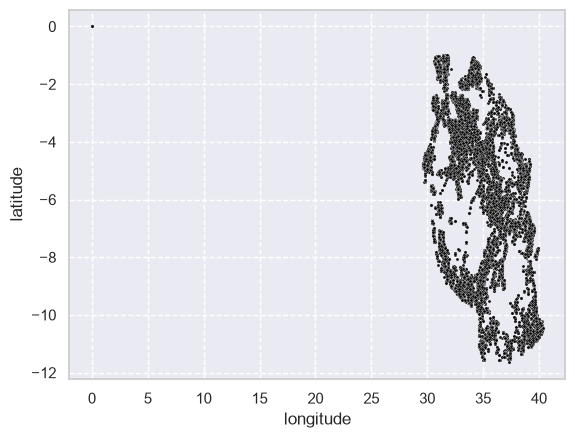

In [108]:
# Scatter plot de las variables
sns.scatterplot(data=X_train, x='longitude', y='latitude', alpha=0.9, s=5, color='black')

In [109]:
# Valores de 'longitude' y 'latitude' que no tengan sentido en Tanzania
print((X_train['latitude'] > -0.1).sum())
print((X_train['longitude'] < 29).sum()) 
print("\n",(X_train['longitude'] < 29).value_counts(normalize=True)) 

1409
1409

 longitude
False    0.970331
True     0.029669
Name: proportion, dtype: float64


In [110]:
# Relación de valores erróneos con la target
pd.crosstab(X_train['longitude'] < 28, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
longitude,,,
False,0.544855,0.068400,0.386745
True,0.484031,0.212207,0.303762


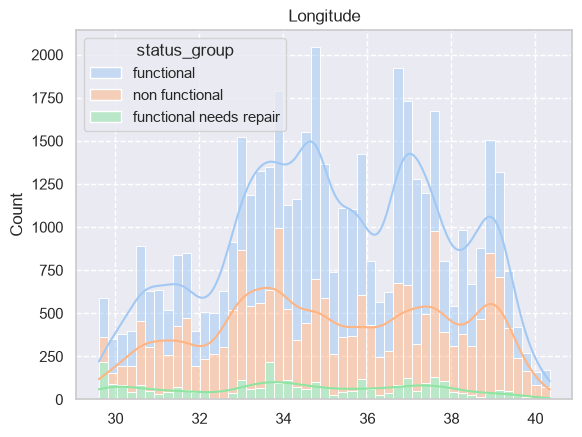

In [111]:
# Distribución de longitude
sns.histplot(data=X_train[X_train['longitude'] > 0], x='longitude', hue=y_train, multiple='stack', kde=True)
plt.title("Longitude")
plt.xlabel("")
plt.show()

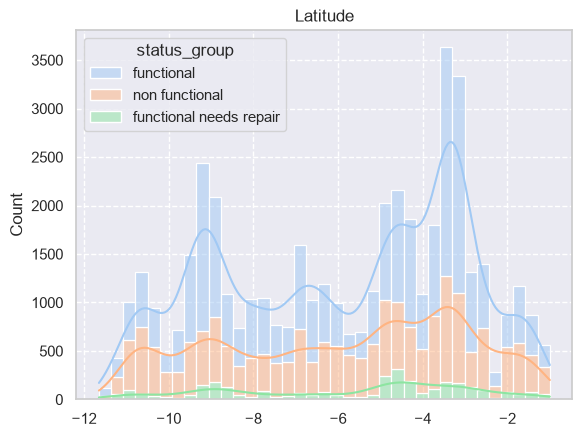

In [112]:
# Distribución de latitude
sns.histplot(data=X_train[X_train['latitude'] < -0.1], x='latitude', hue=y_train, multiple='stack', kde=True)
plt.title("Latitude")
plt.xlabel("")
plt.show()

Conclusiones de `longitude` & `latitude`:
- Hay 1409 filas (3% de los datos) que presentan coordenadas erróneas, geográficamente imposibles en Tanzania, apreciables en el scatter plot.
- Estos registros presentan una tasa de functional needs repair notablemente más alta que el resto (21%), por lo que el indicador de coordenadas erróneas puede ser una señal valiosa para distinguir la clase minoritaria de la target.
- Se plantea tramificar las variables, sin embargo, no se obser vaun patrón lineal claro al analizar sus distribución en relación a la target.

**Decisión:** se conservan ambas variables como numéricas, pendiente de tratar las coordenadas erróneas. Además, ante los resultados de las coordenadas erróneas frente a la target, se plantea crear un indicador de falta de coordenadas, útil para la clase minoritaria.

#### - `gps_height` 
La altitud de Tanzana va desde 0 a 5895 m, siendo la altitud media entre los 850 y 1000 metros.

In [113]:
# Valores erróneos o raros de gps_height
print("Valores igual a cero:",(X_train['gps_height'] == 0).sum())
print("Valores negativos:",(X_train['gps_height'] < 0).sum())
print("\nPorcentaje valores igual a cero:",(X_train['gps_height'] == 0).value_counts(normalize=True))
print("\nPorcentaje valores menor a cero:",(X_train['gps_height'] < 0).value_counts(normalize=True))

Valores igual a cero: 16305
Valores negativos: 1205

Porcentaje valores igual a cero: gps_height
False    0.656672
True     0.343328
Name: proportion, dtype: float64

Porcentaje valores menor a cero: gps_height
False    0.974627
True     0.025373
Name: proportion, dtype: float64


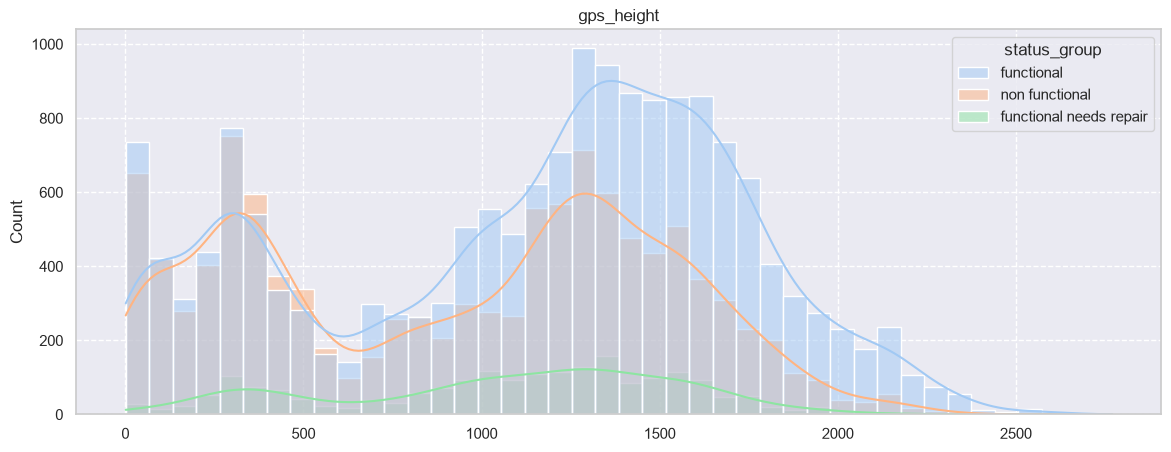

In [114]:
# Distribución de gps_height
plt.figure(figsize=(14,5))
sns.histplot(data=X_train[X_train['gps_height'] > 0], x='gps_height', hue=y_train, kde=True)
plt.title("gps_height")
plt.xlabel("")
plt.show()

In [115]:
# Relación de valores igual a 0 con la target
pd.crosstab(X_train['gps_height'] == 0, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
gps_height,,,
False,0.559386,0.065831,0.374784
True,0.511806,0.085741,0.402453


In [116]:
# Relación de valores menor a 0 con la target
pd.crosstab(X_train['gps_height'] < 0, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
gps_height,,,
False,0.543685,0.073802,0.382513
True,0.518672,0.029046,0.452282


In [117]:
# Relación con valores igual a 0 en gps_height y valores erróneos de longitude
((X_train['gps_height'] == 0) & (X_train['longitude'] < 29)).sum()

np.int64(1409)

Conclusiones de `gps_height`:
- Hay 16305 valores igual a cero, lo cual resulta muy improbable que un 34% de los pozos estén a la altura del mar.
- Hay 1205 (2%) valores negativos, tratandose de valores imposibles para Tanzania.
- En la distribución donde excluyen los valores negativos e iguales a cero, se observa un pico cercano a cero que pueden tratarse también de un error. La distribución es bimodal y existe variación en la proporción de functional y non functional entre ambas franjas.
- Los valores igual a 0 o negativos tienen tasas muy parecidas en relación con la target, teniendo una proporción de non functional superior a la media.
- Los registros erróneos de 'longitude' coinciden con los valores igual a 0 de 'gps_height'.

**Decisión:** conservar la variable como numérica y queda pendiente el tratamiento de los valores negativos e iguales a cero por tratarse de errores. Se plantea crear un indicador de valor erróneo en gps_height, dado el volumen elevado del problema y para preservar la señal, aunque sea modesta.

#### - `basin` 

In [118]:
# Distribución de basin
X_train.basin.value_counts(normalize=True)

basin
Lake Victoria              0.171885
Pangani                    0.150913
Rufiji                     0.134046
Internal                   0.131583
Lake Tanganyika            0.107705
Wami / Ruvu                0.099640
Lake Nyasa                 0.086374
Ruvuma / Southern Coast    0.076457
Lake Rukwa                 0.041397
Name: proportion, dtype: float64

In [119]:
# Relación de basin con la target
pd.crosstab(X_train.basin, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
basin,,,
Internal,0.580733,0.069451,0.349816
Lake Nyasa,0.652365,0.050707,0.296928
Lake Rukwa,0.406918,0.112411,0.480671
Lake Tanganyika,0.483871,0.114956,0.401173
Lake Victoria,0.493814,0.095063,0.411123
Pangani,0.602902,0.053997,0.343100
Rufiji,0.633836,0.056236,0.309928
Ruvuma / Southern Coast,0.369044,0.074084,0.556871
Wami / Ruvu,0.524725,0.044379,0.430896


Conclusiones de `basin`:
- La distribución está razonablemente equilibrada.
- Hay diferencias en las proporciones de la target de cada categoría.

**Decisión:** se conserva 'basin' como variable categórica.

#### - `subvillage` 

In [120]:
# Cardinalidad de subvillage
X_train.subvillage.nunique()

17186

In [121]:
# Distribución de subvillage (categorías top)
X_train.subvillage.value_counts(normalize=True).head(15)

subvillage
Shuleni       0.008688
Majengo       0.008498
Madukani      0.008264
Kati          0.006124
Mtakuja       0.004153
Sokoni        0.003836
M             0.002988
Muungano      0.002903
Songambele    0.002564
Mbuyuni       0.002564
Mlimani       0.002437
Msikitini     0.002352
Miembeni      0.002289
1             0.002161
Kibaoni       0.001950
Name: proportion, dtype: float64

In [122]:
# Nulos de subvillage
X_train.subvillage.isna().sum()

np.int64(301)

Conclusiones de `subvillage`:
- Cardinalidad altísima con 17186 categorías, teniendo la categoría más frecuente un 0,8% de los datos.
- 301 valores nulos, además de valores sospechosos ("M", "1") entre las categorías más frecuentes.
- La información de esta variable puede ser recogida por otras con menos granularidad como region.

**Decisión:** se elimina 'subvillage' por su cardinalidad imposible de manejar y ausencia de concentración que aporte señal.

#### - `region` & `region_code`

In [123]:
# Relación entre region y region_code
pd.crosstab(X_train.region, X_train.region_code)

region_code,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,24,40,60,80,90,99
region,,,,,,,,,,,,,,,,,,,,,,,,,,,
Arusha,0,2423,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,256,0,0,0,0,0
Dar es Salaam,0,0,0,0,0,0,643,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dodoma,1748,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Iringa,0,0,0,0,0,0,0,0,0,0,4215,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Kagera,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2643,0,0,0,0,0,0,0,0,0
Kigoma,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2251,0,0,0,0,0,0,0,0,0,0,0
Kilimanjaro,0,0,3496,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Lindi,0,0,0,0,0,0,0,243,0,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,998,0,0
Manyara,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1274,0,0,0,0,0,0


In [124]:
# V de Cramer: correlación entre variable y target
print("region:", cramers_v(X_train.region, y_train))
print("region_code:", cramers_v(X_train.region_code, y_train))

region: 0.20079477053572314
region_code: 0.2084046952708919


In [125]:
# Distribución de 'region'
X_train.region.value_counts()

region
Iringa           4215
Shinyanga        3977
Mbeya            3742
Kilimanjaro      3496
Morogoro         3164
Arusha           2679
Kagera           2643
Mwanza           2429
Kigoma           2251
Ruvuma           2114
Pwani            2104
Tanga            2066
Dodoma           1748
Singida          1663
Mara             1596
Tabora           1590
Rukwa            1452
Mtwara           1396
Manyara          1274
Lindi            1249
Dar es Salaam     643
Name: count, dtype: int64

In [126]:
# Relación entre 'region' y la target
pd.crosstab(X_train.region, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
region,,,
Arusha,0.687570,0.050019,0.262411
Dar es Salaam,0.562986,0.004666,0.432348
Dodoma,0.469108,0.088673,0.442220
Iringa,0.782918,0.023725,0.193357
Kagera,0.516459,0.087779,0.395762
Kigoma,0.491337,0.209240,0.299422
Kilimanjaro,0.603547,0.075801,0.320652
Lindi,0.296237,0.060048,0.643715
Manyara,0.627159,0.062009,0.310832


Conclusiones de `region` & `region_code`:
- La redundancia entre variables no es total ya que hay regiones que aparecen asociadas a más de un 'region_code'. 
- Hay códigos que parecen errores (24, 60, 80, 90, 99).
- La V de Cramer es ligeramente superior en 'region_code', pero se puede deber a una mayor cardinalidad y el incremento es ínfimo, por lo que no es suficientemente justificable elegir 'region_code' por este motivo.

**Decisión:** se conserva 'region' y se elimina 'region_code' porque se prioriza la fiabilidad de texto y por la incosistencia de codificación.

#### - `district_code`

In [127]:
# Cardinalidad de district_code
print("district_code:", X_train.district_code.nunique())

district_code: 20


In [128]:
# Distribución de district_code
display(pd.DataFrame({
    'conteo': X_train['district_code'].value_counts(normalize=False),
    'porcentaje': X_train['district_code'].value_counts(normalize=True)
}))

,conteo,porcentaje
district_code,,
1,9759,0.205492
2,8880,0.186983
3,8039,0.169274
4,7143,0.150407
5,3467,0.073003
6,3256,0.068560
7,2727,0.057421
8,827,0.017414
30,800,0.016845


In [129]:
# Relación de distric_code con la target
(pd.crosstab(X_train.district_code, y_train, normalize='index')).reindex(X_train['district_code'].value_counts().index)

status_group,functional,functional needs repair,non functional
district_code,,,
1,0.539809,0.104416,0.355774
2,0.557770,0.073761,0.368468
3,0.494464,0.072521,0.433014
4,0.619068,0.058099,0.322834
5,0.569368,0.042400,0.388232
6,0.501229,0.059275,0.439496
7,0.608728,0.059406,0.331867
8,0.573156,0.051995,0.374849
30,0.680000,0.083750,0.236250


Conclusiones de `district_code`:
- Hay 20 categorías pero no son numéricas pese al tipo de int ya que representa un código administrativo sin significado de magnitud.
- La distribución muestra concentración de valores en unas pocas categorías, con algunas categorías con un número muy reducido de datos (67, 80 o 0).
- Las categorías menos frecuenten presentan tasas extremas frente a la target

**Decisión:** se conserva 'district_code' como variable categórica, teniendo en cuenta la existencia de categorías con poca frecuencia que deberán ser tratadas posteriormente en las fases de preprocesado o modelado.

#### `lga`

In [130]:
# Cardinalidad de lga
X_train.lga.nunique()

125

In [131]:
# Distribución de lga
display(pd.DataFrame({
    'conteo': X_train['lga'].value_counts(normalize=False),
    'porcentaje': X_train['lga'].value_counts(normalize=True)
}))

,conteo,porcentaje
lga,,
Njombe,1987,0.041840
Moshi Rural,1000,0.021057
Arusha Rural,993,0.020909
Bariadi,938,0.019751
Rungwe,901,0.018972
...,...,...
Moshi Urban,62,0.001306
Kigoma Urban,58,0.001221
Arusha Urban,51,0.001074


In [132]:
# Relación de top de lga con la target
top_lga = X_train['lga'].value_counts().head(15).index
pd.crosstab(X_train[X_train['lga'].isin(top_lga)]['lga'], y_train, normalize='index')

status_group,functional,functional needs repair,non functional
lga,,,
Arusha Rural,0.703927,0.039275,0.256798
Bagamoyo,0.726356,0.002522,0.271122
Bariadi,0.490405,0.346482,0.163113
Kasulu,0.598549,0.183797,0.217654
Kibondo,0.517192,0.075931,0.406877
Kilombero,0.520672,0.087855,0.391473
Kilosa,0.539352,0.068287,0.392361
Kyela,0.401146,0.010029,0.588825
Mbozi,0.438188,0.070991,0.490820


Conclusiones de `lga`:
- Alta cardinalidad, con 125 categorías.
- Hay patrones distintos frente a la target en las categorías más frecuentes, pudiendo aportar señal.

**Decisión:** se conserva 'lga' como variable categórica, pendiente de tratar la cardinalidad y las categorías pequeñas.

#### `ward`

In [133]:
# Cardinalidad de ward
X_train.ward.nunique()

2087

In [134]:
# Distribución de ward
display(pd.DataFrame({
    'conteo': X_train['ward'].value_counts(normalize=False),
    'porcentaje': X_train['ward'].value_counts(normalize=True)
}))

,conteo,porcentaje
ward,,
Igosi,249,0.005243
Imalinyi,197,0.004148
Siha Kati,193,0.004064
Mdandu,191,0.004022
Nduruma,170,0.003580
...,...,...
Bombambili,1,0.000021
Burungura,1,0.000021
Kining'inila,1,0.000021


In [135]:
# Relación de 'ward' con 'lga'
X_train.groupby('lga')['ward'].nunique().describe()

count    125.000000
mean      17.464000
std        7.055705
min        1.000000
25%       12.000000
50%       17.000000
75%       22.000000
max       37.000000
Name: ward, dtype: float64

Conclusiones de `ward`:
- Tiene una cardinalidad alta, con más de 2000 categorías, siendo Igosi la categoría más frecuente y con solo un 0,5% del total de los datos.
- Cada 'lga' contiene 17 'ward' aproximadamente, por lo que añade mucha granularidad.

**Decisión:** se elimina 'ward' por su cardinalidad y relación con 'lga'.

#### Clasificar variables

In [136]:
# Clasificar geography_cols en cat_cols, num_cols. bin_cols y discard_cols
num_cols.extend(['longitude', 'latitude', 'gps_height'])
cat_cols.extend(['basin', 'region', 'district_code', 'lga'])
discard_cols.extend(['subvillage', 'region_code', 'ward'])

### Análisis variables de tiempo y uso

In [137]:
X_train[use_cols]

,date_recorded,construction_year,population
52797,2012-10-18,0,0
49162,2013-02-18,2000,0
46439,2013-03-14,2012,2000
55120,2013-12-03,1998,200
54803,2011-04-08,0,0
...,...,...,...
4589,2013-01-20,1985,30
39435,2013-02-11,2006,540
15857,2011-07-07,0,0
22190,2011-03-23,1998,100


#### `date_recorded`
Para explorar la variable, es necesario transformar el tipo de dato a datetime.

In [138]:
# Transformar a datetime
X_train['date_recorded'] = pd.to_datetime(X_train['date_recorded'])
X_val['date_recorded'] = pd.to_datetime(X_val['date_recorded'])
X_test['date_recorded'] = pd.to_datetime(X_test['date_recorded'])

In [139]:
# Distribución de meses
X_train.date_recorded.dt.month.value_counts(normalize=True)

date_recorded
3     0.301952
2     0.208482
7     0.115959
1     0.107641
10    0.092270
4     0.066918
8     0.056937
11    0.022973
12    0.010318
6     0.005706
5     0.005538
9     0.005306
Name: proportion, dtype: float64

In [140]:
# Relación de meses con la target
pd.crosstab(X_train.date_recorded.dt.month, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
date_recorded,,,
1,0.409429,0.125196,0.465376
2,0.553479,0.075245,0.371276
3,0.616946,0.049861,0.333194
4,0.521082,0.111391,0.367527
5,0.593156,0.034221,0.372624
6,0.752768,0.033210,0.214022
7,0.498638,0.077719,0.423643
8,0.513683,0.078033,0.408284
9,0.646825,0.027778,0.325397


In [141]:
# Distribución de años
display(pd.DataFrame({
    'conteo': X_train.date_recorded.dt.year.value_counts(normalize=True),
    'porcentaje': X_train.date_recorded.dt.year.value_counts(),
}))

,conteo,porcentaje
date_recorded,,
2011,0.481965,22889
2013,0.409109,19429
2012,0.108442,5150
2004,0.000463,22
2002,0.000021,1


In [142]:
# Relación de años con la target
pd.crosstab(X_train.date_recorded.dt.year, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
date_recorded,,,
2002,1.000000,0.000000,0.000000
2004,0.318182,0.045455,0.636364
2011,0.565774,0.063131,0.371095
2012,0.485631,0.057282,0.457087
2013,0.531731,0.088013,0.380256


In [143]:
# Relación con 'construction_year'
pd.crosstab(X_train.construction_year, X_train.date_recorded.dt.year)

date_recorded,2002,2004,2011,2012,2013
construction_year,,,,,
0,1,8,10623,4125,1770
1960,0,0,11,0,74
1961,0,0,8,0,9
1962,0,0,8,0,14
1963,0,0,11,0,61
1964,0,0,9,14,15
1965,0,0,3,2,12
1966,0,0,11,0,2
1967,0,1,26,5,36


Conclusiones de `date_recorded`:
- La variables es inicialmente tipo object y se ha transformado a datetime.
- La distribución de meses es manejable y aporta señal frente a la target ya que se observa variación en las tasas de cada clase.
- La distribución de los años tiene una concentración en los años 2011, 2012 y 2013, mientras que 2002 y 2004 tienen muy pocos valores.
- Hay datos de 2004 que son erróneos ya que su año de construcción es posterior a su año de registro, lo cual es imposible.
- Por sí sola, la variable no resulta útil por su cardinalidad, sino que su valor está en la creación de nuevas variables.

**Decisión:** se transforma a datetime y se eliminará después de crear nuevas variables a partir de esta (mes del año, año de registro). Los valores anómalos de 2002 y 2004 quedan pendiente de decidir su tratamiento. 

#### `construction_year`

In [144]:
# Distribución de construction_year
display(pd.DataFrame({
    'conteo': X_train.construction_year.value_counts(normalize=True),
    'porcentaje': X_train.construction_year.value_counts(),
}))

,conteo,porcentaje
construction_year,,
0,0.348003,16527
2010,0.044366,2107
2008,0.043924,2086
2009,0.043292,2056
2000,0.034659,1646
2007,0.027016,1283
2006,0.024847,1180
2011,0.021478,1020
2003,0.021436,1018


In [145]:
# Relación de valores igual a 0 en construction_year con la target
pd.crosstab(X_train['construction_year']==0, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
construction_year,,,
False,0.560909,0.065657,0.373434
True,0.509590,0.085799,0.404611


In [146]:
# Relación de construction_year y la target
pd.crosstab(X_train.construction_year, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
construction_year,,,
0,0.509590,0.085799,0.404611
1960,0.258824,0.047059,0.694118
1961,0.117647,0.117647,0.764706
1962,0.318182,0.045455,0.636364
1963,0.361111,0.069444,0.569444
1964,0.184211,0.026316,0.789474
1965,0.588235,0.000000,0.411765
1966,0.307692,0.000000,0.692308
1967,0.382353,0.161765,0.455882


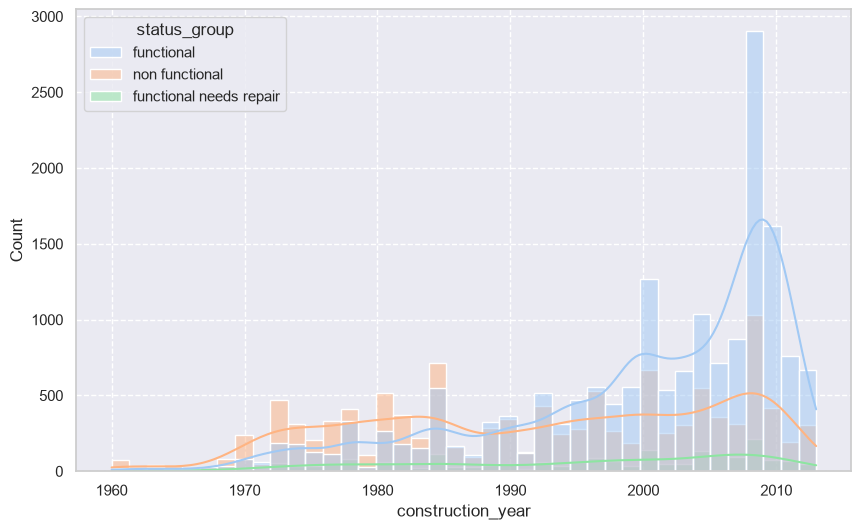

In [147]:
# Histograma de constuction_year con la target
plt.figure(figsize=(10,6))
sns.histplot(x=X_train[X_train['construction_year'] > 0]['construction_year'], hue=y_train, kde=True)
plt.show()

Conclusiones de `construction_year`:
- Hay registros desde 1966 a 2010, cardinalidad moderada y concentración creciente hacia los años más recientes.
- Un 35% de los registros son igual a cero, tratándose de un nulo disfrazado. Estos tienen un porcentaje mayor de non functional en relación a la media, pero sigue siendo débil su señal.
- Se observa que patrón gradiente en el que cuanto más reciente es el año, va creciendo la tasa de functional.

**Decisión:** se conserva 'construction_year' como numérica pendiente de imputar los valores igual a cero. Se plantea crear una nueva variable que indique si el registro es erróneo para conservar la información perdida en la imputación.

#### `population`

In [148]:
# Estadísticos de population
X_train.population.describe()

count    47491.000000
mean       180.006212
std        473.742226
min          0.000000
25%          0.000000
50%         25.000000
75%        220.000000
max      30500.000000
Name: population, dtype: float64

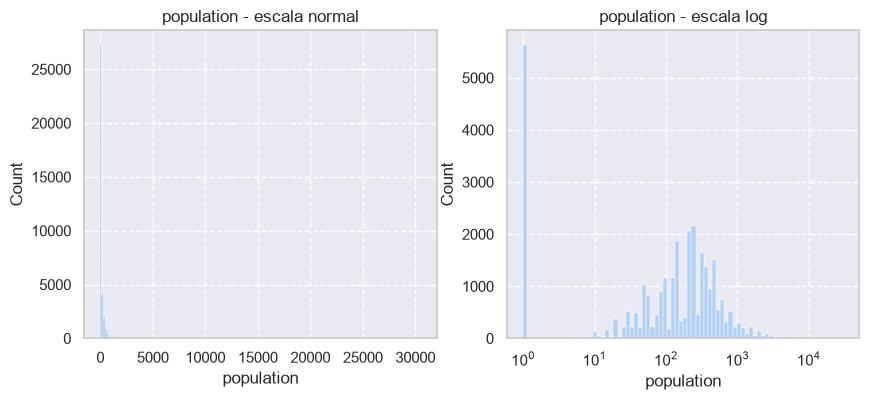

In [149]:
# Histograma de population
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(X_train.population)
plt.title("population - escala normal")
plt.subplot(1,2,2)
sns.histplot(X_train[X_train['population'] > 0]['population'], log_scale=True)
plt.title("population - escala log")
plt.show()

In [150]:
# Valores de population igual a 0
(X_train['population'] == 0).value_counts(normalize=True)

population
False    0.641153
True     0.358847
Name: proportion, dtype: float64

In [151]:
# Valores de population igual a 1
(X_train['population'] == 1).value_counts(normalize=True)

population
False    0.881493
True     0.118507
Name: proportion, dtype: float64

In [152]:
# Relación de valores de population igual a 0 con la target
pd.crosstab((X_train['population'] == 0), y_train, normalize='index')

status_group,functional,functional needs repair,non functional
population,,,
False,0.551709,0.067194,0.381096
True,0.527579,0.082443,0.389978


In [153]:
# Relación de valores de population igual a 1 con la target
pd.crosstab((X_train['population'] == 1), y_train, normalize='index')

status_group,functional,functional needs repair,non functional
population,,,
False,0.560471,0.075484,0.364045
True,0.413468,0.051706,0.534826


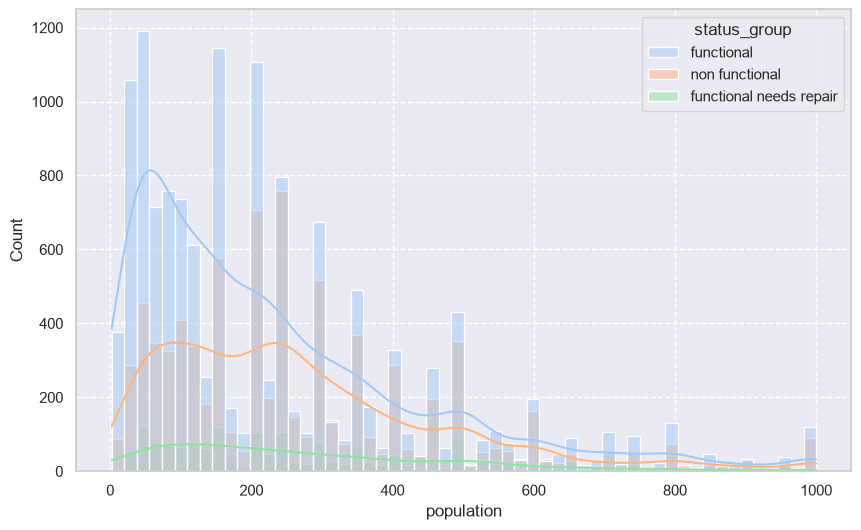

In [154]:
# Distribución de population (ignorando los valores 0 y 1, hasta 1000)
mask = (X_train["population"] > 1) & (X_train["population"] <= 1000)
X_filtrado = X_train[mask]
y_filtrado = y_train[mask]

plt.figure(figsize=(10, 6))
sns.histplot(
    data=X_filtrado,
    x="population",
    hue=y_filtrado,
    kde=True,
    stat="count",
)
plt.show()

In [155]:
# Relación de la población con la target (por quintiles)
mask = X_train['population'] > 0

quintiles = pd.qcut(X_train.loc[mask, 'population'], q=5, duplicates='drop')

pd.crosstab(quintiles, y_train.loc[mask], normalize='index')

status_group,functional,functional needs repair,non functional
population,,,
"(0.999, 18.0]",0.443551,0.048572,0.507877
"(18.0, 100.0]",0.667627,0.059136,0.273237
"(100.0, 205.0]",0.591055,0.072272,0.336673
"(205.0, 396.0]",0.505505,0.075596,0.418899
"(396.0, 30500.0]",0.544454,0.081512,0.374035


Conclusiones de `population`:
- La mitad de los datos tienen una población menor a 25 y un 36% del total tiene valor cero, lo cual probablemente sea un error de registro ya que no tiene sentido instalar un pozo de agua donde no hay población. El valor 1 está presente en un 11% de los registros, probablemente sea otro missing disfrazado.
- Los valores 0 no tienen un patrón distinto a la media frente a la target pero los valores igual a 1 presentan un mayor porcentaje de non functional (53%), lo que sugiere que ambos son datos erróneos o desconocidos con comportamientos diferenciados.
- La distribución de los valores válidos está muy sesgada con un máximo de 15300 y una concentración de los valores entre los 100-200.
- En relación a los cuantiles con la target, presentan mayor porcentaje de functional aquellos con una población baja-media.

**Decisión:** se conserva 'population' como variable numérica pendiente de tratar los valores 0 y 1. Valorar transformación logarítmica dada la distribución sesgadda para aquellos modelos lineales.

#### Clasificar variables

In [156]:
# Clasificar use_cols en cat_cols, num_cols, bin_cols y discard_cols
num_cols.extend(['construction_year', 'population'])
discard_cols.append('date_recorded') # antes se crearán las variables propuestas

## Análisis de registros erróneos
Dado que un elevado número de variables contienen categorías erróneas con patrones claros frente a la target, se va a calcular el número de errores en total que tiene cada fila y relacionar el número de errores con la target.

In [157]:
# Cáculo de número de errores
errores = pd.DataFrame({
    'amount_tsh_0': X_train['amount_tsh'] == 0,
    'water_quality_unknown': X_train['water_quality'] == 'unknown',
    'quantity_unknown': X_train['quantity'] == 'unknown',
    'source_unknown': X_train['source'] == 'unknown',
    'scheme_management_nan': X_train['scheme_management'].isna(),
    'scheme_name_nan': X_train['scheme_name'].isna(),
    'permit_nan': X_train['permit'].isna(),
    'public_meeting_nan': X_train['public_meeting'].isna(),
    'management_unknown': X_train['management'] == 'unknown',
    'payment_unknown': X_train['payment'] == 'unknown',
    'funder_missing': X_train['funder'].isna() | (X_train['funder']=='0'),
    'installer_missing': X_train['installer'].isna() | (X_train['installer']=='0'),
    'longitude_bad': X_train['longitude'] < 29,
    'latitude_bad': X_train['latitude'] > -0.1,
    'gps_height_bad': X_train['gps_height'] <= 0,
    'subvillage_nan': X_train['subvillage'].isna(),
    'construction_year_0': X_train['construction_year'] == 0,
    'population_bad': X_train['population'].isin([0,1]),
})

errores['n_errores'] = errores.sum(axis=1)
cuenta = errores['n_errores'].value_counts().sort_index()
porcentaje = errores['n_errores'].value_counts(normalize=True).sort_index()

display(pd.DataFrame({
    'conteo': cuenta,
    'porcentaje': porcentaje,
}))

,conteo,porcentaje
n_errores,,
0,7527,0.158493
1,8145,0.171506
2,8494,0.178855
3,4169,0.087785
4,5318,0.111979
5,7808,0.164410
6,1723,0.036281
7,2843,0.059864
8,918,0.019330


In [158]:
# Relación de número de errores con la target
pd.crosstab(errores['n_errores'], y_train, normalize='index')

status_group,functional,functional needs repair,non functional
n_errores,,,
0,0.715424,0.096054,0.188521
1,0.603683,0.059791,0.336525
2,0.513421,0.058630,0.427949
3,0.426241,0.049652,0.524107
4,0.434938,0.059233,0.505829
5,0.527408,0.061860,0.410733
6,0.489843,0.091120,0.419037
7,0.508266,0.186775,0.304960
8,0.396514,0.035948,0.567538


**Conclusión: calidad de registro como señal**

- Se observa que las filas sin ningún missing (15% del dataset según el conjunto de variables consideradas) presentan una tasa de functional 
notablemente superior a la media (71% frente a 54%), sugiriendo que la completitud del registro es, en sí misma, una señal indirecta de mejor mantenimiento del pozo, más allá del contenido específico de cada variable individual. 

Sin embargo, más allá de la distinción sin missing o con al menos un missing, el patrón no es monótono ni fiable en profundidad: no se observa una relación clara de a más missing simultáneos, peor estado, y los grupos con muchos missing a la vez (a partir de 10 o más errores) tienen muestras demasiados reducidas para extraer conclusiones sólidas. 

**Decisión:** los valores nulos o erróneos deben formar parte del modelo de alguna manera, pudiéndose crear variables que indiquen el error de registro en ciertas variables para evitar la pérdida de esta información con la imputación o manteniendo dichos valores como categorías propias. La estrategia dependerá del modelo a utilizar, dado que algunos permiten valores nulos y otros no.

## Análisis de categorías con alta cardinalidad
Ante la existencia de varias variables con un número alto de categorías y baja concentración de datos en algunas de ellas, se debe comprobar si hay categorías que existen en test o en el conjunto de validación pero no en train. Ello podría causar fallos en el modelo ya que si no existen en train, no tiene formar de aprender sobre esa categoría. 

In [159]:
for col in cat_cols:
    categorias_train = set(X_train[col].dropna().unique())
    categorias_val = set(X_val[col].dropna().unique())
    categorias_test = set(test_features[col].dropna().unique())
    total_categorias = set(df[col].dropna().unique())
    nuevas_categorias_val = categorias_val - categorias_train
    nuevas_categorias_test = categorias_test - categorias_train
    if nuevas_categorias_val:
        print(f'{col}: {len(nuevas_categorias_val)} categorías nuevas en validación (de {len(total_categorias)} totales)')
    if nuevas_categorias_test:
        print(f'{col}: {len(nuevas_categorias_test)} categorías nuevas en test (de {len(total_categorias)} totales)')

funder: 216 categorías nuevas en validación (de 1896 totales)
funder: 262 categorías nuevas en test (de 1896 totales)
installer: 215 categorías nuevas en validación (de 2145 totales)
installer: 288 categorías nuevas en test (de 2145 totales)


## Cálculo de V de Cramer de todas las variables

In [160]:
# V de Cramer de todas las variables
resultados = {}

for c in cat_cols:
    x = X_train[c].fillna('missing').astype(str) #fillna para que los nulos cuenten como categoría propia y no queden excluídos
    resultados[c] = cramers_v(x, y_train)

for c in bin_cols:
    x = X_train[c].fillna('missing').astype(str)
    resultados[c] = cramers_v(x, y_train)

for c in num_cols:
    binned = pd.qcut(X_train[c], q=5, duplicates='drop') # se discretizan en cuantiles para poder aplicar la V de Cramer
    resultados[c + ' (binned)'] = cramers_v(binned, y_train)

resumen_v_cramer = pd.Series(resultados).sort_values(ascending=False)
print(resumen_v_cramer.round(4))

installer                     0.3569
funder                        0.3485
lga                           0.3114
quantity                      0.3108
waterpoint_type               0.2513
extraction_type               0.2482
region                        0.2008
payment                       0.1837
amount_tsh (binned)           0.1776
source                        0.1491
construction_year (binned)    0.1491
water_quality                 0.1366
management                    0.1333
scheme_management             0.1293
basin                         0.1279
longitude (binned)            0.1218
district_code                 0.1193
gps_height (binned)           0.1000
population (binned)           0.0878
latitude (binned)             0.0633
public_meeting                0.0578
permit                        0.0283
dtype: float64


## Multicolinealidad de variables numéricas

<Axes: >

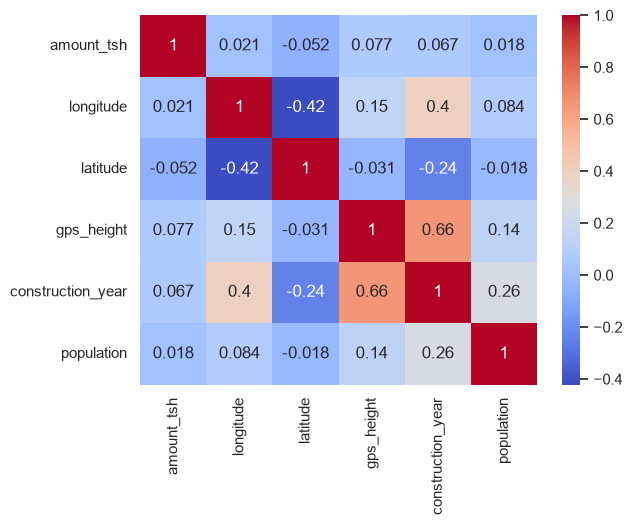

In [161]:
# Heatmap de correlaciones de variables numéricas
sns.heatmap(X_train[num_cols].corr(), annot=True, cmap='coolwarm')

## Conclusiones del EDA

### 1. Variables conservadas y descartadas

De las 40 variables originales, tras el análisis por bloques temáticos:

**Conservadas — categóricas (16):** `water_quality`, `quantity`, `source`, `waterpoint_type`, `scheme_management`, `permit`, `public_meeting`, `management`, `payment`, `funder`, `installer`, `extraction_type`, `basin`, `region`, `district_code`, `lga`

**Conservadas — numéricas (6):** `amount_tsh`, `longitude`, `latitude`, `gps_height`, `construction_year`, `population`

**Descartadas (18):** `id` (identificador), `recorded_by` (varianza cero), `quality_group`, `quantity_group`, `source_type`, `source_class`, `waterpoint_type_group`, `extraction_type_group`, `extraction_type_class`, `management_group`, `payment_type` (todas redundantes con su versión más granular), `scheme_name`, `wpt_name`, `subvillage`, `ward` (cardinalidad inmanejable sin concentración aprovechable), `region_code` (inconsistencias de codificación), `num_private` (varianza casi nula, sin señal), `date_recorded` (se transformará en variables derivadas)

### 2. Ranking de poder discriminatorio (Cramér's V frente a la target)

Como cierre cuantitativo del EDA, se calculó el Cramér's V de todas las variables conservadas (numéricas discretizadas en cuantiles) frente al 
target:

| Variable | V de Cramer |
|---|---|
| installer* | 0.3569 |
| funder* | 0.3485 |
| lga* | 0.3114 |
| quantity | 0.3108 |
| waterpoint_type | 0.2513 |
| extraction_type | 0.2482 |
| region | 0.2008 |
| payment | 0.1837 |
| amount_tsh | 0.1776 |
| source | 0.1491 |
| construction_year | 0.1491 |
| water_quality | 0.1366 |
| management | 0.1333 |
| scheme_management | 0.1293 |
| basin | 0.1279 |
| longitude | 0.1218 |
| district_code | 0.1191 |
| gps_height | 0.0985 |
| population | 0.0878 |
| latitude | 0.0648 |
| public_meeting | 0.0576 |
| permit | 0.0297 |

> `installer`, `funder` y `lga` tienen cardinalidad alta, lo que infla artificialmente el estadístico. Su posición real en el ranking probablemente sea algo menor de lo que sugiere el número. Se mantienen en el modelo por el valor cualitativo confirmado en el análisis por bloques, no solo por esta V de Cramer. Asimismo, las variables numéricas han sido tramificadas por cuantiles, pudiendo perder la información real de su valor predictivo.

Descontando ese sesgo, las variables con mayor poder discriminatorio fiable son: **`quantity`**, **`waterpoint_type`**, **`extraction_type`** y **`region`**, candidatas a ser las más importantes en el modelo final.

### 3. Patrones detectados

- **La categoría unknown/nulo suele ser informativa, no aleatoria**: se repite en `quantity`, `water_quality`, `payment`, `management`, `funder`, `installer`, `longitude` y `latitude`, mostrando sistemáticamente peor tasa de funcionamiento que la media.

- **La completitud del registro es una señal**: las filas sin ningún missing disfrazado muestran tasas de `functional` por encima de la media (70% frente al 54% base). Además, missings, valores erróneos o valores igual a 0 o unknown, sugiriendo un proceso de captura de datos defectuoso en un subconjunto identificable del

- **Varias variables jerárquicas** (`extraction_type`, `waterpoint_type`, `source`) pierden poder predictivo real al agregarse a niveles superiores. Se ha priorizado sistemáticamente el nivel más granular que sí aportaba señal diferenciada.
  
### 4. Pendientes para las siguientes fases 

- **Tratamiento de nulos:** imputar o tratar como categoría a los nulos de `permit`, `public_meeting`, `scheme_management`, `funder` e `installer`, así como los nulos disfrazados o valores erróneos de `amount_tsh`, `funder`, `installer`, `longitude`, `latitude`, `gps_height`, `construction_year` y `population`.

- **Tratamiento de outliers:** normalizar la distribución sesgada de `population` para aquellos modelos que necesiten una distribución gaussiana.

- **Tratamiento de variables con alta cardinalidad:** aplicar agrupamiento de categorías en aquellas variables con alta cardinalidad para los modelos lineales y no realizar modificaciones para los modelos basados en árboles, que manejan bien la cardinalidad. Estas son `funder`, `installer` y `lga`. Tener en cuenta que las dos primeras variables tienen categorías en los conjuntos de test y validación que no existen en train.

- **Tratamiento de variables con alta concentración en uno o muy pocos valores:** decidir si binarizar, agrupar o no realizar modificaciones en  variables como `amount_tsh`, `scheme_management` y `management`.

- **Tratamiento de categorías de muestras reducidad:** agrupar, aplicar Target Encoding con suavizado o utilizar hiperparámetros durante la fase de modelado para resolver el problema de categorías que tienen muy poca concentración de valores, pudiendo crear sobreajuste. Las variables afectadas son `water_quality`, `waterpoint_type`, `extraction_type` y `district_code`, así como las variables con alta cardinalidad.

- **Feature Engineering:** crear variables fecha derivadas de `date_recorded`, variable binaria que indique si existe diferencia entre `scheme_management`y `management`, variables que indiquen error de registro.

- **Encoding de categóricas:** convertir categóricas en numéricas o variables derivadas binarias para aquellos modelos que no permitan datos de tipo texto.

- **Eliminar variables descartadas:** eliminar `id`, `recorded_by`, `quality_group`, `quantity_group`, `source_type`, `source_class`, `waterpoint_type_group`, `extraction_type_group`, `extraction_type_class`, `management_group`, `payment_type`, `scheme_name`, `wpt_name`, `subvillage`, `ward`, `region_code`, `num_private` y `date_recorded` 

# 4. Preprocesamiento & Feature Engineering

## Variables fecha derivadas de `date_recorded`

Se van a extraer dos variables que pueden aportar valor: un indicador del año e indicador del mes. 

In [162]:
# Crear variable indicador de año
X_train['year_recorded'] = X_train.date_recorded.dt.year
X_val['year_recorded'] = X_val.date_recorded.dt.year
X_test['year_recorded'] = X_test.date_recorded.dt.year

# Crear variable indicador de mes
X_train['month_recorded'] = X_train.date_recorded.dt.month
X_val['month_recorded'] = X_val.date_recorded.dt.month
X_test['month_recorded'] = X_test.date_recorded.dt.month

In [163]:
# Distribución de 'year_recorded' en todos los conjuntos
display(pd.DataFrame({
    'X_train': X_train['year_recorded'].value_counts(),
    'X_val': X_val['year_recorded'].value_counts(),
    'X_test': X_test['year_recorded'].value_counts()
}))

,X_train,X_val,X_test
year_recorded,,,
2001,NaN,NaN,1.0
2002,1.0,NaN,NaN
2004,22.0,8.0,11.0
2011,22889.0,5772.0,7234.0
2012,5150.0,1261.0,1665.0
2013,19429.0,4832.0,5939.0


Los años 2001, 2002 y 2004 tienen muy pocos valores, quedando pendiente su tratamiento como se mencionó en el EDA.

In [164]:
# Clasificar nuevas variables
cat_cols.append('month_recorded')
num_cols.append('year_recorded')

## Valores incoherentes de `year_recorded` y `construction_year`

Hay registros cuyo 'year_recorded' es anterior al 'construction_year', lo que resulta imposible. Coincide con los datos de 2004, que además representan un porcentaje ínfimo del dataset, al igual que los valores 2001 y 2002.

In [165]:
X_train.loc[X_train['construction_year'] > X_train['year_recorded']]

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,year_recorded,month_recorded
23373,20534,50.0,2004-03-01,Tasaf And Lga,239,TASAFcitizen and LGA,39.272736,-11.019000,Juhudi,0,Ruvuma / Southern Coast,Mwanona,Mtwara,90,33,Newala,Luchingu,317,True,GeoData Consultants Ltd,VWC,Mwanona,False,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,spring,spring,groundwater,communal standpipe multiple,communal standpipe,2004,3
48555,1251,0.0,2004-12-01,African 2000 Network,284,Karugendo,38.929212,-7.111349,Kauzeni Primary School 2,0,Wami / Ruvu,Kauzeni Chini,Pwani,60,33,Kisarawe,Kibuta,185,True,GeoData Consultants Ltd,Private operator,NaN,False,2008,gravity,gravity,gravity,private operator,commercial,never pay,never pay,soft,good,enough,enough,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,2004,12
32619,9195,0.0,2004-03-01,Caltus,1856,Cultus,31.539761,-7.983106,Kwa Pambajila,0,Lake Tanganyika,Magomeni,Rukwa,15,4,Sumbawanga Urban,Kasense,900,True,GeoData Consultants Ltd,VWC,Mradi wa maji wa kasen,True,2005,gravity,gravity,gravity,vwc,user-group,never pay,never pay,soft,good,dry,dry,spring,spring,groundwater,communal standpipe,communal standpipe,2004,3
13366,48759,100.0,2004-06-01,Mgaya,1331,Mgaya,34.290885,-1.699609,Maro Mgaya,0,Lake Victoria,Kibaoni,Mara,20,2,Serengeti,Kenyamonta,80,NaN,GeoData Consultants Ltd,Other,NaN,True,2011,other - rope pump,rope pump,rope pump,other,other,pay per bucket,per bucket,soft,good,enough,enough,shallow well,shallow well,groundwater,hand pump,hand pump,2004,6
39559,15921,0.0,2004-03-06,Tasafu,301,DWE,38.558421,-5.140405,Shuleni,0,Pangani,Kiwanjani,Tanga,4,2,Korogwe,Kwagunda,713,True,GeoData Consultants Ltd,VWC,NaN,False,2009,other,other,other,vwc,user-group,never pay,never pay,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other,2004,3
33942,5971,0.0,2004-03-01,Amref,-27,AMREF,39.283105,-7.422852,Kwa Ndevu,0,Rufiji,Gundani,Pwani,6,4,Mkuranga,Magawa,200,True,GeoData Consultants Ltd,VWC,NaN,False,2007,swn 80,swn 80,handpump,vwc,user-group,never pay,never pay,soft,good,seasonal,seasonal,shallow well,shallow well,groundwater,hand pump,hand pump,2004,3
27501,53086,500.0,2004-01-07,Kkkt,1611,Villagers,34.900561,-8.873813,Kwa Barnabasi Kilumile,0,Rufiji,Mlowa,Iringa,11,4,Njombe,Makambako,65,True,GeoData Consultants Ltd,VWC,NaN,False,2009,nira/tanira,nira/tanira,handpump,vwc,user-group,pay when scheme fails,on failure,soft,good,enough,enough,hand dtw,borehole,groundwater,hand pump,hand pump,2004,1
10441,55069,20.0,2004-12-01,Plan Int,307,DDCA,38.768656,-7.298419,Mianzi Primary School,0,Rufiji,Momboni,Pwani,60,33,Kisarawe,Msanga,1,True,GeoData Consultants Ltd,VWC,NaN,False,2006,india mark iii,india mark iii,handpump,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,spring,spring,groundwater,hand pump,hand pump,2004,12


Al analizar ambas variables, se consiera que 'construction_year' da mayores motivos para desconfiar de ella dado que ya presentaba un 34% de valores igual a cero. 

**Decisión:** las filas incoherentes (construction_year > year_recorded) se convertirán en NaN y se tratarán igual que el resto de missings de la variable.

In [166]:
# Convertir datos incoherentes de 'construction_year' en nulos
for data in [X_train, X_val, X_test]:
    incoherentes = data['construction_year'] > data['year_recorded']
    data.loc[incoherentes, 'construction_year'] = np.nan

## Errores de registro

Anteriormente se ha planteado la creación de variables indicadoras de un error de registro. Se consideran las siguientes opciones:
-  Indicador binario por cada variable: crear variables que indiquen si existe un error de registro en una variable en concreto (por ejemplo, 0 en amount_tsh, 0 en construction_year)
-  Indicador binario a nivel agregado: variable que indique si la fila tiene al menos un error de registros o no en cualquiera de las variables.
-  Indicador de número de errores a nivel agregado: variable que capture el número de errores de registro de cada fila.

Tras un análisis más detallado, se descartan las variables agregadas y se opta por crear indicadores binarios individuales por variable por los siguientes motivos:
- Duplicación de señal: varias de las categorías "unknown" (`water_quality`, `quantity`, `source`, `management`, `payment`) ya se conservan como categoría propia dentro de sus respectivas variables categóricas (decisión tomada en el EDA), por lo que el modelo ya tiene acceso directo a esa información a través del encoding. Incluirlas también en un indicador agregado sería representar la misma información dos veces.
- La variable agregada estaría sesgada por variables que se van a binarizar aparte: el hallazgo del EDA de que "0 errores → 71% functional" estaba inflado en parte por variables como `amount_tsh` (70% de ceros) y las coordenadas erróneas, que de por sí ya se iban a tratar con su propio indicador individual. Al quitar esas variables del conteo agregado, el patrón pierde buena parte de su fuerza aparente, lo que indica que la señal real vivía en esas variables concretas, no en el agregado en sí.
- Indicadores individuales permiten que el modelo aprenda el peso real de cada tipo de missing por separado, en vez de forzar a que todos pesen igual dentro de una suma, cuando ya sabíamos por el EDA que algunas señales eran más fuertes que otras.

La creación de dichas variables se realizará durante el tratamiento de nulos.

## Valores nulos

Tratamiento de valores NaN y nulos disfrazados o datos erróneos.

#### - `permit` & `public_meeting`

En el EDA se comprobó mediante V de Cramer que el valor nulo no muestra un comportamiento diferenciado del resto en ninguna de las dos variables, de hecho, tratarlo como categoría propia reducía ligeramente la asociación con el target. Ambas variables  tienen poder discriminatorio bajo en general, por lo que el método de imputación escogido no afectará demasiado a los resultados. 

**Decisión:** se imputa con la moda de cada variable en X_train (True en ambos casos), que, además, es consistente con la evidencia de que el grupo con nulo se aproxima más al comportamiento general del dataset, especialmente en 'permit'.

In [167]:
# Imputar con moda
imputer_moda = SimpleImputer(strategy='most_frequent')
X_train[['permit', 'public_meeting']] = imputer_moda.fit_transform(X_train[['permit', 'public_meeting']])
X_test[['permit', 'public_meeting']] = imputer_moda.transform(X_test[['permit', 'public_meeting']])
X_val[['permit', 'public_meeting']] = imputer_moda.transform(X_val[['permit', 'public_meeting']])

#### - `scheme_management`

Ante la concentración de datos en un solo valor (VWC) y la señal que proporcionan los nulos frente a la target (tiene un mayor porcentaje de non functional respecto a la media), tratar los nulos como una categoría propia puede aportar más información que su imputación. Además, existen 3115 nulos, por lo que sería la tercera categoría más representada en 'scheme_management'.

**Decisión:** se tratan como categoría propia.

In [168]:
# Imputar con unknown
imputer_unknown = SimpleImputer(strategy='constant', fill_value='unknown')
X_train[['scheme_management']] = imputer_unknown.fit_transform(X_train[['scheme_management']])
X_test[['scheme_management']] = imputer_unknown.transform(X_test[['scheme_management']])
X_val[['scheme_management']] = imputer_unknown.transform(X_val[['scheme_management']])

#### - `funder` & `installer`

Ambas variables comparten 2940 nulos en el conjunto train. Al igual que otras variables, el valor desconocido tiene un patrón distinto, siendo, en este caso, más propenso a functional needs repair que la media. Asimismo, 620 valores son igual a 0, siendo también valores nulos. Estos, sin embargo, tienen unas tasas distintas a los valores NaN, por lo que se tratarán como categorías diferentes para no perder información. 

**Decisión:** imputarlo como categoría 'unknown' para mantener el valor predictivo que puede ayudar a la clase minoritaria. No realizar modificaciones a aquellos valores igual a cero.

In [169]:
# Imputar con unknown
X_train[['funder', 'installer']] = imputer_unknown.fit_transform(X_train[['funder', 'installer']])
X_test[['funder', 'installer']] = imputer_unknown.transform(X_test[['funder', 'installer']])
X_val[['funder', 'installer']] = imputer_unknown.transform(X_val[['funder', 'installer']])

#### - `amount_tsh`

El 70% del conjunto train tiene valor igual a 0, con una señal clara respecto a la target, siendo conveniente binarizarla. 

**Decisión:** crear una copia para binarizar la variable como indicador de que el valor sea igual a 0. Para no perder información, se mantendrá la variable original para posteriormente comparar cuál ofrece mejores resultados.

In [170]:
# Binarizar variable
X_train['amount_tsh_missing'] = (X_train['amount_tsh'] == 0).astype(int)
X_test['amount_tsh_missing'] = (X_test['amount_tsh'] == 0).astype(int)
X_val['amount_tsh_missing'] = (X_val['amount_tsh'] == 0).astype(int)

In [171]:
# Actualizar clasificación de variables
bin_cols.append('amount_tsh_missing')

#### - `longitude` & `latitude`

No tiene nulos pero si coordenadas erróneas. Dado que se van a comparar distintos modelos, algunos que manejan nulos y otros que no, se va a realizar distintas estrategias. 

**Decisión:** crear una copia de la variable para realizar imputación de los nulos, creando además un indicador de 
coordenadas incorrectas para no perder información. Se mantendrá la variable original sin transformaciones también para realizar comparaciones.

Para la imputación, se opta por el método de KNN Imputer aprovechando las variables geográficas de 'region', 'district_code' y 'lga', ya que imputará cada coordenada con el promedio ponderado de las coordenadas de los pozos más parecidos geográficamente, combinando información de varios niveles jerárquicos en vez de uno solo. El coste computacional es mayor pero asumible dado el tamaño del dataset. 

Para poder realizar esta imputación, se deben convertir las coordenadas consideradas erróneas como nulos para poder tratarlos como tal y se codifican las variables categóricas escogidas (KNN solo actúa sobre nulos y necesita datos numéricos dado que calcula distancias). La codificación se combina con las variables 'longitude' y 'latitude' escaldadas para aplicar el KNNImputer con k=5, buscando los 5 vecinos más parecidos utilizando solo esas variables.

Debido a la complejidad del código para introducirlo en un pipeline durante el modelo y dado que es la única estrategia de imputación que se va a realizar, se imputa directamente en esta fase.

In [172]:
# Crear variable de coordenadas nulas
X_train['coords_missing'] = (X_train['longitude'] < 29).astype(int)  # longitude y latitude fallan a la vez, solo se necesita un indicador
X_test['coords_missing'] = (X_test['longitude'] < 29).astype(int)  
X_val['coords_missing'] = (X_val['longitude'] < 29).astype(int)  

In [173]:
# Convertir las coordenadas erróneas en nulos
X_train.loc[X_train['coords_missing'] == 1, ['longitude', 'latitude']] = np.nan
X_test.loc[X_test['coords_missing'] == 1, ['longitude', 'latitude']] = np.nan
X_val.loc[X_val['coords_missing'] == 1, ['longitude', 'latitude']] = np.nan

In [174]:
# Codificar las categorías de región
geografia_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
geo_encoded_train = geografia_encoder.fit_transform(X_train[['region', 'district_code', 'lga']].astype(str))
geo_encoded_test = geografia_encoder.transform(X_test[['region', 'district_code', 'lga']].astype(str))
geo_encoded_val = geografia_encoder.transform(X_val[['region', 'district_code', 'lga']].astype(str))

In [175]:
# Escalar longitude/latitude 
coord_scaler = StandardScaler()
coords_train_scaled = coord_scaler.fit_transform(X_train[['longitude', 'latitude']])
coords_test_scaled = coord_scaler.transform(X_test[['longitude', 'latitude']])
coords_val_scaled = coord_scaler.transform(X_val[['longitude', 'latitude']])

In [176]:
# Combinar con longitude y latitude para imputar
datos_knn_train = np.hstack([geo_encoded_train, coords_train_scaled])
datos_knn_test = np.hstack([geo_encoded_test, coords_test_scaled])
datos_knn_val = np.hstack([geo_encoded_val, coords_val_scaled])

In [177]:
# Imputar con KKNImputer
knn_imputer = KNNImputer(n_neighbors=5)
datos_imputados_train = knn_imputer.fit_transform(datos_knn_train)
datos_imputados_test = knn_imputer.transform(datos_knn_test)
datos_imputados_val= knn_imputer.transform(datos_knn_val)

In [178]:
# Crear variables imputadas 'longitude' y 'latitude' con los valores imputados
X_train[['longitude_imputed', 'latitude_imputed']] = datos_imputados_train[:, -2:]
X_test[['longitude_imputed', 'latitude_imputed']] = datos_imputados_test[:, -2:]
X_val[['longitude_imputed', 'latitude_imputed']] = datos_imputados_val[:, -2:]

In [179]:
# Actualizar clasificación de variables
num_cols.extend(['longitude_imputed', 'latitude_imputed'])
bin_cols.append('coords_missing')

#### - `gps_height`

Al igual que con longitude y latitude, se opta por KNNImputer, reutilizando la codificación one-hot de 'region', 'district_code' y 'lga' ya calculada anteriormente, y añadiendo además 'longitude_imputed' y 'latitude_imputed',  dado que la altitud está fuertemente ligada tanto a la administración geográfica como a la posición exacta del pozo y las coordenadas aportan una señal más precisa.

**Decisión:** crear variable indicadora de valores erróneos e imputar en una variable nueva para los modelos que no aceptan nulos, manteniendo la variable original con los valores erróneos como NaN para los modelos que sí los gestionan de forma nativa.


Para el proceso, se realizan los mismos pasos, convirtiendo los valores erróneos en nulos para poder aplicar la imputación y reutilizando la codificación de one-hot ya calculada anteriormente. También se aplica StandardScaler como en el caso anterior para evitar que las distintas escalas numéricas distorsiones el cáculo de distancias del KNN. Este escalado se deshace al finalizar el proceso.

In [180]:
# Crear variable de 'gps_height' nula 
X_train['gps_height_missing'] = (X_train['gps_height'] <= 0).astype(int)
X_test['gps_height_missing'] = (X_test['gps_height'] <= 0).astype(int)
X_val['gps_height_missing'] = (X_val['gps_height'] <= 0).astype(int)

In [181]:
# Convertir los datos erróneos en nulos
X_train.loc[X_train['gps_height_missing'] == 1, 'gps_height'] = np.nan
X_test.loc[X_test['gps_height_missing'] == 1, 'gps_height'] = np.nan
X_val.loc[X_val['gps_height_missing'] == 1, 'gps_height'] = np.nan

In [182]:
# Escalar gps_height
height_scaler = StandardScaler()
height_train_scaled = height_scaler.fit_transform(X_train[['gps_height']])
height_test_scaled = height_scaler.transform(X_test[['gps_height']])
height_val_scaled = height_scaler.transform(X_val[['gps_height']])

In [183]:
# Combinar gps_height con la categorías codificadas anteriormente  y las coordenadas imputadas 
datos_knn_height_train = np.hstack([geo_encoded_train, datos_imputados_train, height_train_scaled])
datos_knn_height_test = np.hstack([geo_encoded_test, datos_imputados_test, height_test_scaled])
datos_knn_height_val = np.hstack([geo_encoded_val, datos_imputados_val, height_val_scaled])

In [184]:
# Imputar con KNNImputer
knn_imputer_gps = KNNImputer(n_neighbors=5)
datos_imputados_train_height = knn_imputer_gps.fit_transform(datos_knn_height_train)
datos_imputados_test_height = knn_imputer_gps.transform(datos_knn_height_test)
datos_imputados_val_height = knn_imputer_gps.transform(datos_knn_height_val)

In [185]:
# Crear variable para imputar los valores
X_train['gps_height_imputed'] = datos_imputados_train_height[:, -1]
X_test['gps_height_imputed'] = datos_imputados_test_height[:, -1]
X_val['gps_height_imputed'] = datos_imputados_val_height[:, -1]

In [186]:
# Actualizar clasificación de variables
num_cols.extend(['gps_height_imputed'])
bin_cols.append('gps_height_missing')

In [187]:
# Deshacer escalado
X_train[['longitude_imputed', 'latitude_imputed']] = coord_scaler.inverse_transform(datos_imputados_train_height[:, -3:-1])
X_train['gps_height_imputed'] = height_scaler.inverse_transform(datos_imputados_train_height[:, -1].reshape(-1, 1))

X_test[['longitude_imputed', 'latitude_imputed']] = coord_scaler.inverse_transform(datos_imputados_test_height[:, -3:-1])
X_test['gps_height_imputed'] = height_scaler.inverse_transform(datos_imputados_test_height[:, -1].reshape(-1, 1))

X_val[['longitude_imputed', 'latitude_imputed']] = coord_scaler.inverse_transform(datos_imputados_val_height[:, -3:-1])
X_val['gps_height_imputed'] = height_scaler.inverse_transform(datos_imputados_val_height[:, -1].reshape(-1, 1))

#### - `population`

Se sigue la misma estrategia que anteriormente respecto a la creación de variables de missings e imputed. En este caso, se descarta KNNImputer por el volumen de missings (47%) y una señal débil con la target, no compensando el coste computacional de esta estrategia.

**Decisión:** se opta por la mediana calculada a partir de las variables 'ward', 'lga' y 'region' de X_train y la mediana global para aquellas regiones que no se pueda calcular (debido precisamente a la cantidad de missings). De manera que, si no puede calcular la mediana de 'ward', imputa con la mediana de 'lga' y, a su vez, si tampoco es calculable, se pasa a la mediana de 'region' y finalmente la mediana global.

In [188]:
# Crear variable 'population_missing'
X_train['population_missing'] = (X_train['population'].isin([0, 1])).astype(int)
X_test['population_missing'] = (X_test['population'].isin([0, 1])).astype(int)
X_val['population_missing'] = (X_val['population'].isin([0, 1])).astype(int)

In [189]:
# Convertir valores erróneos de 'population' en nulos
X_train.loc[X_train['population_missing'] == 1, 'population'] = np.nan
X_test.loc[X_test['population_missing'] == 1, 'population'] = np.nan
X_val.loc[X_val['population_missing'] == 1, 'population'] = np.nan

In [190]:
# Crear copia de la variable 'population' en la que hacer la imputación
X_train['population_imputed'] = X_train['population']
X_test['population_imputed'] = X_test['population']
X_val['population_imputed'] = X_val['population']

In [191]:
# Imputar por mediana según 'ward', 'lga' o 'region'
nivel_geografico = ['ward', 'lga', 'region']

for nivel in nivel_geografico:
    mediana = X_train.groupby(nivel)['population'].median()
    X_train['population_imputed'] = X_train['population_imputed'].fillna(X_train[nivel].map(mediana))
    X_test['population_imputed'] = X_test['population_imputed'].fillna(X_test[nivel].map(mediana))
    X_val['population_imputed'] = X_val['population_imputed'].fillna(X_val[nivel].map(mediana))

# Imputar con mediana global (por si quedara algún nulo)
mediana_global = X_train['population'].median()
X_train['population_imputed'] = X_train['population_imputed'].fillna(mediana_global)
X_test['population_imputed'] = X_test['population_imputed'].fillna(mediana_global)
X_val['population_imputed'] = X_val['population_imputed'].fillna(mediana_global)

In [192]:
# Actualizar clasificación de variables
num_cols.extend(['population_imputed'])
bin_cols.append('population_missing')

#### - `construction_year`

Un 34% de los datos son missing y no hay ninguna variable que pueda aproximarse bien al dato real como ocurría con el resto de variables. En este caso, la mayor aproximación que se podría hacer es utilizando las variables de 'funder' o 'installer' dado que los pozos no se construyen de forma aislada, sino en el marco de campañas de instalación. Asimismo, pueden influir también las variables geográficas ya que es razonable esperar que los pozos de una misma región tiendan a agruparse en periodos de construcción similares.

**Decisión:** al igual que en las anteriores variables, se crea un indicador de missing para construction_year y se imputa en una nueva variable, dejando la original con los valores NaN. Para la impuación, se opta por la mediana calculada a partir de la variable 'region' de X_train y la mediana global para aquellas regiones que no se pueda calcular (debido precisamente a la cantidad de missings). 

In [193]:
# Crear variable de 'construction_year' missing
X_train['construction_year_missing'] = (X_train['construction_year'] == 0).astype(int)
X_test['construction_year_missing'] = (X_test['construction_year'] == 0).astype(int)
X_val['construction_year_missing'] = (X_val['construction_year'] == 0).astype(int)

In [194]:
# Convertir valores igual a 0 de 'construction_year' en nulos
X_train.loc[X_train['construction_year_missing'] == 1, 'construction_year'] = np.nan
X_test.loc[X_test['construction_year_missing'] == 1, 'construction_year'] = np.nan
X_val.loc[X_val['construction_year_missing'] == 1, 'construction_year'] = np.nan

In [195]:
# Crear copia de variable para imputación
X_train['construction_year_imputed'] = X_train['construction_year']
X_test['construction_year_imputed'] = X_test['construction_year']
X_val['construction_year_imputed'] = X_val['construction_year']

In [196]:
# Imputar mediana por región
mediana_global_year = X_train['construction_year'].median()
mediana_region_year = X_train.groupby('region')['construction_year'].median()

for data in [X_train, X_val, X_test]:
    mascara_missings_year = data['construction_year_imputed'].isna()
    valores_imputados = data.loc[mascara_missings_year, 'region'].map(mediana_region_year).fillna(mediana_global_year)
    data.loc[mascara_missings_year, 'construction_year_imputed'] = valores_imputados

In [197]:
# Actualizar clasificación de variables
num_cols.extend(['construction_year_imputed'])
bin_cols.append('construction_year_missing')

## Variables con alta cardinalidad

#### - `funder` & `installer`

Las variables 'funder' e 'installer' presentan una elevada cardinalidad, lo que puede suponer un problema para determinados algoritmos. No obstante, algunos modelos basados en árboles son capaces de manejar esta alta cardinalidad de forma eficiente. 

**Decisión:** crear una copia de las variables para la reducción de categorías en estas y mantener las originales para los modelos que manejen bien la cardinalidad con el objetivo de comparar resultados entre modelos. Previamente, se normalizará el texto ante la presencia de categorías iguales (por ejemplo, Government y government).

In [198]:
# Normalizar texto
X_train.funder = (X_train.funder.str.lower().str.strip())
X_train.installer = (X_train.installer.str.lower().str.strip())

X_test.funder = (X_test.funder.str.lower().str.strip())
X_test.installer = (X_test.installer.str.lower().str.strip())

X_val.funder = (X_val.funder.str.lower().str.strip())
X_val.installer = (X_val.installer.str.lower().str.strip())

In [199]:
# Crear copia de variables 
X_train['funder_reduced'] = X_train.funder.copy()
X_train['installer_reduced'] = X_train.installer.copy()

X_test['funder_reduced'] = X_test.funder.copy()
X_test['installer_reduced'] = X_test.installer.copy()

X_val['funder_reduced'] = X_val.funder.copy()
X_val['installer_reduced'] = X_val.installer.copy()

In [200]:
# Agrupar categorías en otros
top_funders = X_train['funder'].value_counts().nlargest(10).index
top_installers = X_train['installer'].value_counts().nlargest(10).index

for data in [X_train, X_val, X_test]:
    data['funder_reduced'] = data['funder'].where(data['funder'].isin(top_funders), other='Other')
    data['installer_reduced'] = data['installer'].where(data['installer'].isin(top_installers), other='Other')

In [201]:
# Actualizar clasificación de variables
cat_cols.extend(['funder_reduced', 'installer_reduced'])

#### - `lga`

La cardinalidad es menor que en las anteriores pero existen categorías con muy pocos valores.

**Decisión:** crear una copia de la variable en la que fusionar en una categoría 'Other' todas las categorías que no estén en el top 20.

In [202]:
# Crear una copia de lga
X_train['lga_reduced'] = X_train.lga.copy()
X_test['lga_reduced'] = X_test.lga.copy()
X_val['lga_reduced'] = X_val.lga.copy()

In [203]:
# Agrupar categorías en otros
top_lga = X_train['lga'].value_counts().nlargest(20).index

for data in [X_train, X_val, X_test]:
    data['lga_reduced'] = data['lga'].where(data['lga'].isin(top_lga), other='Other')

In [204]:
# Actualizar clasificación de variables
cat_cols.append('lga_reduced')

## Tratamiento de categorías de muestras reducidas

Las variables `water_quality`, `waterpoint_type`, `extraction_type`, `district_code`, así como las variables originales con alta cardinalidad tratadas anteriormente poseen ciertas categorías con muestras muy reducidas, siendo poco fiables para un modelo, que puede aprender un patrón generalizable. 

**Decisión:** se revisan una a una las variables de cardinalidad baja y se agrupan las categorías reducidas con la categoría más afín semánticamente dentro de la misma variable (en vez de un "Other" genérico), dado que el volumen afectado es mínimo y el resto de categorías de estas variables no presentan este problema. En el caso de las variables originales de alta cardinalidad no se aplica ningún tratamiento adicional sobre estas categorías, sino que será en la fase de modelado cuando se solucione este problema con el uso de hiperparámetros de regularización. Estos impiden que el modelo cree particiones basadas en un número de observaciones demasiado pequeño para ser fiable.

- `water_quality` agrupar fluoride abandoned con fluoride.
- `waterpoint_type` agrupar dam con other.
- `extraction_type` agrupar other - mkulima/shinyanga con other.
- `district_code` no se agrupan ya que no tienen relación entre ellos.

In [205]:
# water_quality: agrupar 'fluoride abandoned' con 'fluoride'
for data in [X_train, X_val, X_test]:
    data['water_quality'] = data['water_quality'].replace({'fluoride abandoned': 'fluoride'})

# waterpoint_type: agrupar 'dam' con 'other'
for data in [X_train, X_val, X_test]:
    data['waterpoint_type'] = data['waterpoint_type'].replace({'dam': 'other'})

# extraction_type: agrupar 'other - mkulima/shinyanga' con 'other'
for data in [X_train, X_val, X_test]:
    data['extraction_type'] = data['extraction_type'].replace({'other - mkulima/shinyanga': 'other'})

## Creación variable `different_management`

La variable 'management' indica quién gestiona el pozo en la práctica, mientras que 'scheme_management' indica quién gestiona el "scheme" (organización) al que pertenece el pozo formalmente. Ambas variables representan conceptos muy próximos y comparten categorías casi idénticas, por lo que una discrepancia entre ellas puede ser indicativa de un conflicto o falta de claridad organizativa en la gestión del pozo, una señal potencialmente relevante para el estado de funcionamiento del pozo.

**Decisión:** se crea la variable binaria 'different_management', que indica si 'management' y 'scheme_management' no coinciden para una misma fila. Antes de comparar, se normalizan ambas variables (minúsculas, sin espacios) para evitar falsos positivos derivados de diferencias de formato entre columnas, no de contenido real. También se unifica la categoría "other - school" de 'management' con su equivalente "swc" de 'scheme_management' (ambas representan el mismo concepto con nomenclatura distinta).

In [206]:
# Normalizar texto
for data in [X_train, X_val, X_test]:
    data.management = data.management.str.lower().str.strip()
    data.scheme_management = data.scheme_management.str.lower().str.strip()

In [207]:
# Modificar valor other - school
for data in [X_train, X_val, X_test]:
    data['management'] = data['management'].replace('other - school', 'swc')

In [208]:
# Crear variable
for data in [X_train, X_val, X_test]:
    data['different_management'] = (data['scheme_management'] != data['management']).astype(int)

In [209]:
# Relación de 'different_management' con la target 
pd.crosstab(X_train.different_management, y_train, normalize='index')

status_group,functional,functional needs repair,non functional
different_management,,,
0,0.543218,0.068332,0.388450
1,0.542170,0.095376,0.362454


La nueva variable muestra que si existe diferencia, el porcentaje de functional needs repair es mayor que la media, por lo que puede ayudar a proporcionar información al modelo sobre la clase minoritaria.

In [210]:
# Actualizar clasificación de variables
bin_cols.append('different_management')

## Creación variables `pump_age` & `pump_age_imputed`

La antigüedad del pozo (diferencia entre el año de registro y el año de construcción) es un indicador 
potencialmente relevante para el estado de funcionamiento (cabe esperar que pozos más antiguos tengan mayor probabilidad de estar averiados o necesitar reparación. No obstante, anteriormente se trataron los errores de registro de 'construction_year', por lo que para es necesario continuar con el mismo criterio para le creación de una variable indicadora de la antigüedad del pozo.

**Decisión:** se crean dos versiones de la variable_
- pump_age: calculada a partir de construction_year (con NaN), para modelos que admiten valores nulos.
- pump_age_imputed: calculada a partir de construction_year_imputed, sin nulos, para modelos que no los admiten.

In [211]:
# Creación de las variables
for data in [X_train, X_val, X_test]:
    data['pump_age'] = data['year_recorded'] - data['construction_year']
    data['pump_age_imputed'] = data['year_recorded'] - data['construction_year_imputed']

In [212]:
# Actualizar clasificación de variables
num_cols.extend(['pump_age', 'pump_age_imputed'])

# 5. Modelado

## Modelo 1: Logistic Regression

Como primer modelo se elige una regresión logística, que sirve de baseline simple e interpretable frente a comparar modelos más complejos en fases posteriores.

**Preprocesamiento dentro del pipeline:**
- Variables numéricas: se seleccionan la versión _imputed sin nulos, estandarizadas con StandardScaler, necesario para un modelo lineal que es sensible a la escala de las variables.
- Variables categóricas: se seleccionan todas las variables, con la versión _reduced de las de alta cardinalidad, y se codifican con One-Hot Enconding-
- Variables binarias: se seleccionan todas y no se aplican transformaciones.

In [213]:
# Feature Selection
cat_reduced = ['water_quality', 'quantity', 'source', 'waterpoint_type',
               'scheme_management', 'management', 'payment', 'extraction_type',
               'basin', 'region', 'district_code', 'month_recorded', 'funder_reduced',
               'installer_reduced', 'lga_reduced']
num_imputed = ['year_recorded', 'longitude_imputed', 'latitude_imputed', 'gps_height_imputed',
               'population_imputed', 'construction_year_imputed', 'pump_age_imputed']

In [214]:
# Preprocesado + Modelo
logistic_preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_imputed),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_reduced),
    ('bin', 'passthrough', bin_cols)
])

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', logistic_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=seed
    ))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_val_log = logistic_pipeline.predict(X_val)

In [215]:
# Validación 
print("Accuracy:", accuracy_score(y_val, y_pred_val_log))
print("F1 macro:", f1_score(y_val, y_pred_val_log, average='macro'))
print(classification_report(y_val, y_pred_val_log))
print(confusion_matrix(y_val, y_pred_val_log))

cv_score = cross_val_score(logistic_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score))
print("Standard deviation: ", np.std(cv_score))

Accuracy: 0.7430304051208625
F1 macro: 0.5728209714889562
                         precision    recall  f1-score   support

             functional       0.73      0.89      0.80      6447
functional needs repair       0.57      0.13      0.21       863
         non functional       0.78      0.66      0.71      4563

               accuracy                           0.74     11873
              macro avg       0.69      0.56      0.57     11873
           weighted avg       0.74      0.74      0.72     11873

[[5710   44  693]
 [ 579  108  176]
 [1522   37 3004]]

Resultados validación cruzada:
Mean accuracy:  0.7495733733184802
Standard deviation:  0.007071360809841635


In [216]:
# Predicciones sobre el conjunto de test
y_pred_test_log = logistic_pipeline.predict(X_test)

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission1 = pd.DataFrame({
    'id': X_test['id'],
    'status_group': y_pred_test_log
})

submission1.to_csv('01_logistic_regression.csv', index=False)

### Conclusiones del modelo

- **Accuracy: 0.7430** - sensiblemente por encima de predecir siempre la clase mayoritaria (~0.54), lo que indica que el modelo captura señal real pese a su simplicidad.
- **F1 macro: 0.5728** - bastante inferior al accuracy, algo esperado por el desbalanceo de clases.
- **Accuracy cross-validation: 0.7496** - muy consistente con el accuracy en el split de validación simple.

El modelo distingue razonablemente bien functional (recall 0.89) y non functional (recall 0.66), pero es prácticamente incapaz de identificar functional needs repair (recall 0.13): de 863 casos reales de esta clase, solo acierta 108, confundiéndola mayoritariamente con functional. 

>Nota: se ha probado a añadir transformación logarítmica en 'population_imputed' al tener una distribución asimétrica, sin embargo, se obtienen peores resultados, por lo que se mantiene este modelo simple.

#### Score en competición Drive Data
Se suben las predicciones de este modelo sobre el conjunto de test a la competición de DrivenData para obtener el accuracy real sobre datos no vistos, y se registra el resultado como referencia adicional junto a las métricas de validación.

 **Score: 0.7460** - muy consistente con las métricas en local, lo que confirma que no hay overfitting al conjunto de validación ni fugas de información en el pipeline.

## Modelo 2: Decision Tree Classifier

Como segundo modelo se prueba un árbol de decisión, que permite comparar el efecto de un modelo no lineal frente al baseline lineal de Logistic Regression.

**Preprocesamiento dentro del pipeline:**
- Variables numéricas: se seleccionan todas en su versión _imputed y se pasan sin escalar ya que cada split se basa en umbrales por variable de forma independiente.
- Variables categóricas: se seleccionan todas y se codificadan con OrdinalEncoder en vez de One-Hot. Se usan además  las variables originales de alta cardinalidaden vez de sus versiones _reduced, ya que los árboles manejan bien muchas categorías. Se usa handle_unknown='use_encoded_value', unknown_value=-1 para soportar categorías nuevas en validación y test no vistas en train (ya detectado como riesgo en el EDA para funder e installer).
- Variables binarias: se pasan todas igual que en el modelo anterior.
- Control del overfitting: se aplican dos hiperparámetros básicos como primer ajuste: max_depth=10 y min_samples_leaf=20 para solucionar el problema de muestras pequeñas en ciertas categorías con alta cardinalidad.

In [217]:
# Feature Selection
cat_originals = ['water_quality', 'quantity', 'source', 'waterpoint_type',
            'scheme_management', 'management', 'payment', 'funder', 'installer',
            'extraction_type', 'basin', 'region', 'district_code', 'lga',
            'month_recorded']

In [218]:
# Preprocesado + Modelo
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_imputed),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_originals),
    ('bin', 'passthrough', bin_cols)
])

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', DecisionTreeClassifier(random_state=seed))
])

tree_pipeline.fit(X_train, y_train)
y_pred_val_tree = tree_pipeline.predict(X_val)

In [219]:
# Validación 
print("Accuracy:", accuracy_score(y_val, y_pred_val_tree))
print("F1 macro:", f1_score(y_val, y_pred_val_tree, average='macro'))
print(classification_report(y_val, y_pred_val_tree))
print(confusion_matrix(y_val, y_pred_val_tree))

cv_score_dt = cross_val_score(tree_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_dt))
print("Standard deviation: ", np.std(cv_score_dt))

Accuracy: 0.7496841573317612
F1 macro: 0.6440582008272454
                         precision    recall  f1-score   support

             functional       0.80      0.79      0.80      6447
functional needs repair       0.38      0.39      0.38       863
         non functional       0.75      0.76      0.76      4563

               accuracy                           0.75     11873
              macro avg       0.64      0.65      0.64     11873
           weighted avg       0.75      0.75      0.75     11873

[[5091  372  984]
 [ 347  333  183]
 [ 905  181 3477]]

Resultados validación cruzada:
Mean accuracy:  0.7483311882792641
Standard deviation:  0.004856798250633098


In [220]:
# Predicciones sobre el conjunto de test
y_pred_test_tree = tree_pipeline.predict(X_test)

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission2 = pd.DataFrame({
    'id': X_test['id'],
    'status_group': y_pred_test_tree
})

submission2.to_csv('02_decision_tree.csv', index=False)

### Conclusiones del modelo
- **Accuracy: 0.7497** - ligeramente superior a Logistic Regression (0.7430)
- **F1 macro: 0.6441** - moderadamente superior (0.5728)
- **Accuracy cross-validation: 0.7483** - ligeramente inferior a la media de CV de Logistic Regression (0.7496), aunque más estable entre folds (std menor). 

El árbol empeora notablemente el recall de functional (0.89 vs 0.79) pero mejora el de non functional (0.76 vs 0.66). El recall de functional needs repair mejora muy considerablemente (0.39 vs 0.13) que en el modelo lineal.

Cambiar de modelo lineal a no lineal mejora ligeramente el rendimiento global, pero no resuelve el problema de la clase minoritaria ya que el recall sigue siendo bajo. Esto sugiere que el reto con functional needs repair no depende tanto de la forma del modelo (lineal vs árbol), sino del desbalanceo de clases en sí o de la falta de señal distintiva en las variables actuales. Se deberá abordar el desbalanceo de forma más directa en próximos modelos. 

#### Score en competición Drive Data
 **Score: 0.7513** - superior al 0.7460 de Logistic Regression. Aunque en CV el árbol tenía una media ligeramente inferior, en el resultado real sobre datos de test no vistos supera al modelo lineal.

## Modelo 3: Random Forest

Se prueba Random Forest como primer ensemble, pensado específicamente para el overfitting que puede sufrir un árbol individual.

**Preprocesamiento dentro del pipeline:** 
- Se reutiliza el mismo ColumnTransformer que en Decision Tree (OrdinalEncoder para categóricas, incluidas las variables originales de alta cardinalidad sin reducir; numéricas y binarias sin escalar) ya que Random Forest comparte las mismas propiedades de invarianza a la escala y tolerancia a la codificación ordinal arbitraria.

In [221]:
# Modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        random_state=seed,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['functional','functional needs repair','non functional']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](58,)","['id','amount_tsh','date_recorded',...,'different_management','pump_age', 'pump_age_imputed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,58
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns

In [222]:
# Validación
y_pred_train_rf = rf_pipeline.predict(X_train) # Se va a calcular el accuracy de train para analizar overfitting
y_pred_val_rf = rf_pipeline.predict(X_val)

print("Accuracy train:", accuracy_score(y_train, y_pred_train_rf)) 
print("Accuracy val:", accuracy_score(y_val, y_pred_val_rf))
print("F1 macro val:", f1_score(y_val, y_pred_val_rf, average='macro'))
print(classification_report(y_val, y_pred_val_rf))
print(confusion_matrix(y_val, y_pred_val_rf))

cv_score_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf))
print("Standard deviation: ", np.std(cv_score_rf))

Accuracy train: 0.9975784885557264
Accuracy val: 0.8025772761728291
F1 macro val: 0.6969176163470733
                         precision    recall  f1-score   support

             functional       0.81      0.87      0.84      6447
functional needs repair       0.54      0.38      0.45       863
         non functional       0.83      0.78      0.80      4563

               accuracy                           0.80     11873
              macro avg       0.73      0.68      0.70     11873
           weighted avg       0.80      0.80      0.80     11873

[[5620  209  618]
 [ 395  328  140]
 [ 910   72 3581]]

Resultados validación cruzada:
Mean accuracy:  0.800951646759328
Standard deviation:  0.004812088226524964


In [223]:
# Predicciones sobre el conjunto de test
y_pred_test_rf = rf_pipeline.predict(X_test)

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission3 = pd.DataFrame({
    'id': X_test['id'],
    'status_group': y_pred_test_rf
})

submission3.to_csv('03_random_forest.csv', index=False)

### Conclusiones del modelo
- **Accuracy: 0.8026** - aumento mayor que Decision Tree respecto al primer modelo. No obstante, hay un overfitting preocupante si se compara con el accuracy de train (0.9976), debido principalmente a la falta de hiperparámetros que controlen un mínimo de muestras para reducir sobreajuste.
- **F1 macro: 0.6969** - mejora notable frente al anterior (0.6441)
- **Accuracy cross-validation: 0.8010** - ligeramente menor al accuracy de validación, confirma que el resultado es robusto y no depende del split concreto.

Hay una ligera mejora en las tres clases, pero el recall empeora o se mantiene.

#### Score en competición Drive Data
 **Score: 0.8093** - superando claramente a Logistic Regression (0.7460) y Decision Tree (0.7513).

## Modelo 4: Random Forest con GridSearchCV

Tras confirmar que Random Forest supera claramente a los dos modelos anteriores con hiperparámetros elegidos manualmente, se realiza una búsqueda sistemática de hiperparámetros con GridSearchCV para intentar solucionar el overfitting y mejorar aún más el resultado.
>
>En una priméra búsqueda con:
>```Python
> param_grid = {
>    'classifier__n_estimators': [200, 300, 500],
>    'classifier__max_depth': [15, 20, 25],
>    'classifier__min_samples_leaf': [2, 5, 10]
>}
>```
>
>Se obtiene que los mejores hiperparámetros son: {'classifier__max_depth': 25, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300} con **accuracy en CV de 0.8063**

> En una segunda búsqueda con:
> ```Python
> param_grid = {
>    'classifier__n_estimators': [250, 300, 350],
>    'classifier__max_depth': [20, 25, 30],
>    'classifier__min_samples_leaf': [2, 3],
>    'classifier__min_samples_split': [2, 5],
>    'classifier__max_features': ['sqrt', 0.3]
>}
>```
>
> Se obtiene que los mejores hiperparámetros son {'classifier__max_depth': 30, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300} con un **accuracy en CV de 0.8063**, por lo que Random Forest está cerca de su techo con este preprocesado y no es necesario continuar con la búsqueda de hiperparámetros.

In [224]:
# Modelo
rf_best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        random_state=seed,
        n_jobs=-1,
        n_estimators=300,
        max_depth=30,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=5,
    ))
])

rf_best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['functional','functional needs repair','non functional']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](58,)","['id','amount_tsh','date_recorded',...,'different_management','pump_age', 'pump_age_imputed']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,58
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns

In [225]:
# Validación del mejor resultado de GridSearchCV
y_pred_train_rf_grid = rf_best_pipeline.predict(X_train)
y_pred_val_rf_grid = rf_best_pipeline.predict(X_val)

print("Accuracy train:", accuracy_score(y_train, y_pred_train_rf_grid))
print("Accuracy val:", accuracy_score(y_val, y_pred_val_rf_grid))
print("F1 macro val:", f1_score(y_val, y_pred_val_rf_grid, average='macro'))
print(classification_report(y_val, y_pred_val_rf_grid))
print(confusion_matrix(y_val, y_pred_val_rf_grid))

Accuracy train: 0.9204270282790423
Accuracy val: 0.808809904826076
F1 macro val: 0.7007456131647999
                         precision    recall  f1-score   support

             functional       0.80      0.90      0.85      6447
functional needs repair       0.67      0.34      0.45       863
         non functional       0.84      0.77      0.80      4563

               accuracy                           0.81     11873
              macro avg       0.77      0.67      0.70     11873
           weighted avg       0.81      0.81      0.80     11873

[[5774  105  568]
 [ 444  294  125]
 [ 990   38 3535]]


In [226]:
# Predicciones sobre el conjunto de test
y_pred_test_rf_best = rf_best_pipeline.predict(X_test)

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission4 = pd.DataFrame({
    'id': X_test['id'],
    'status_group': y_pred_test_rf_best
})

submission4.to_csv('04_random_forest_tuned.csv', index=False)

### Conclusiones del modelo
- **Accuracy: 0.8088** - aumento ligera y consistente con la CV, pero con una diferencia bastante grande con el accuracy en train (0.9204), lo que puede deberse al min_samples_leaf=2, que puede generar overfitting al ser un hiperparámetro tan permisivo.
- **F1 macro: 0.7007** - aumento ligero respecto a la versión sin ajustar
- **Accuracy cross-validation: 0.8063** - mejora respecto al anterior

El ajuste de hiperparámetros ha mejorado ligeramente los resultados y el overfitting, pero este sigue existiendo y la mejora es tan pequeña que se llega a la conclusión de que este modelo ha llegado a su techo.

#### Score en competición Drive Data
 **Score: 0.8177** - aquí si se aprecia una mejora moderada, superando incluso la validación de CV.

## Modelo 5: Random Forest con SMOTE

Ante el problema del desbalance de clases, que se está trasladando a la ineficacia de los modelos para detectar la clase minoritaria, y dado que el ajuste de hiperparámetros de Random Forest ha alcanzado un techo, en este modelo se prueba SMOTE. Se usan los mismos hiperparámetros del mejor Random Forest encontrado hasta ahora.

El objetivo es observar el cambio en el F1 score ya que lo más probable es que SMOTE mejore el recall a costa de reducir el accuracy global. La competición se evalúa con accuracy por lo que se realiza como experimento, sabiendo que no resultará útil para la misma porque el equilibrio artificial de las clases penalizará el acierto en la clase mayoritaria.

In [227]:
# Modelo
rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('smote', SMOTE(random_state=seed)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=30,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features='sqrt',
        random_state=seed,
        n_jobs=-1
    ))
])

rf_smote_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['functional','functional needs repair','non functional']"
feature_names_in_,"ndarray[object](58,)","['id','amount_tsh','date_recorded',...,'different_management','pump_age', 'pump_age_imputed']"
n_features_in_,int,58
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [228]:
# Validación
y_pred_val_smote = rf_smote_pipeline.predict(X_val)
y_pred_train_smote = rf_smote_pipeline.predict(X_train)

print("Accuracy train:", accuracy_score(y_train, y_pred_train_smote))
print("Accuracy val:", accuracy_score(y_val, y_pred_val_smote))
print("F1 macro val:", f1_score(y_val, y_pred_val_smote, average='macro'))
print(classification_report(y_val, y_pred_val_smote))
print(confusion_matrix(y_val, y_pred_val_smote))

cv_score_rf_smote = cross_val_score(rf_smote_pipeline, X_train, y_train, cv=5, scoring='accuracy')

print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf_smote))
print("Standard deviation: ", np.std(cv_score_rf_smote))

Accuracy train: 0.9271019772167358
Accuracy val: 0.7971868946348859
F1 macro val: 0.7047638954173662
                         precision    recall  f1-score   support

             functional       0.82      0.85      0.83      6447
functional needs repair       0.46      0.49      0.47       863
         non functional       0.83      0.79      0.81      4563

               accuracy                           0.80     11873
              macro avg       0.70      0.71      0.70     11873
           weighted avg       0.80      0.80      0.80     11873

[[5452  377  618]
 [ 333  420  110]
 [ 850  120 3593]]

Resultados validación cruzada:
Mean accuracy:  0.7964454881276528
Standard deviation:  0.0053421212116717956


### Conclusiones del modelo
- **Accuracy: 0.7972** - ha empeorado el resultado como se esperaba
- **F1 macro: 0.7048** - aumenta ligeramente respecto al anterior (0.7007)
- **Accuracy cross-validation: 0.7964** - se reduce también respecto a lo anterior (0.8063)

Los resultados son los esperados, reducción del accuracy y mejora del F1 macro. Dado que los resultados no favorecen en la competición, no se va a realizar ninguna subida de predicciones y no se continuará probando estas técnicas de desbalanceo.

## Modelo 6: LightGB

Como sexto modelo se prueba LightGBM, como primer modelo boosting ya que es rápido de entrenar y maneja bien los datasets grandes.

**Preprocesado:** es necesario que las variables sean de tipo category, por lo que se crea una copia de las variables para realizar la transformación del tipo de dato. En este caso, los valores nulos si los acepta, al igual que otros modelos boosting. Se va a probar con las versiones _imputed para tener una comparación más directa con los modelos anteriores. Asimismo, se probarán las variables originales para conocer también dicha diferencia. Por estos motivos se prioriza la rapidez del modelo y se escoge LightGB como primera opción de boosting.

### LightGB con variables imputadas

In [229]:
# Preprocesado 
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()
X_test_lgb = X_test.copy()

for col in cat_originals:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col] = X_val_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

for col in bin_cols:
        X_train_lgb[col] = X_train_lgb[col].astype(str).astype('category')
        X_val_lgb[col] = X_val_lgb[col].astype(str).astype('category')
        X_test_lgb[col] = X_test_lgb[col].astype(str).astype('category')

features_imputed = num_imputed + cat_originals + bin_cols

# Modelo
lgb_imputed = lgb.LGBMClassifier(random_state=seed, n_jobs=-1, verbosity=-1)

lgb_imputed.fit(
    X_train_lgb[features_imputed], y_train,
    categorical_feature=cat_originals
)

,random_state,25
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [230]:
# Validación
y_pred_train_lgb = lgb_imputed.predict(X_train_lgb[features_imputed])
y_pred_val_lgb = lgb_imputed.predict(X_val_lgb[features_imputed])

print("Accuracy train:", accuracy_score(y_train, y_pred_train_lgb)) 
print("Accuracy val:", accuracy_score(y_val, y_pred_val_lgb))
print("F1 macro val:", f1_score(y_val, y_pred_val_lgb, average='macro'))
print(classification_report(y_val, y_pred_val_lgb))
print(confusion_matrix(y_val, y_pred_val_lgb))

cv_score_rf = cross_val_score(lgb_imputed, X_train_lgb[features_imputed], y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf))
print("Standard deviation: ", np.std(cv_score_rf))

Accuracy train: 0.8328946537238635
Accuracy val: 0.7932283331929588
F1 macro val: 0.6701230713333745
                         precision    recall  f1-score   support

             functional       0.78      0.90      0.83      6447
functional needs repair       0.66      0.28      0.39       863
         non functional       0.83      0.74      0.78      4563

               accuracy                           0.79     11873
              macro avg       0.76      0.64      0.67     11873
           weighted avg       0.79      0.79      0.78     11873

[[5781   87  579]
 [ 489  240  134]
 [1132   34 3397]]

Resultados validación cruzada:
Mean accuracy:  0.7971191545891133
Standard deviation:  0.007832968277566363


### LightGB con variables originales

In [231]:
# Feature selection
num_originals = ['amount_tsh', 'longitude', 'latitude', 'gps_height',
                 'construction_year', 'population', 'year_recorded', 'pump_age']
features_originals = num_originals + cat_originals + bin_cols

# Modelo
lgb_originals = lgb.LGBMClassifier(random_state=seed, n_jobs=-1, verbosity=-1)

lgb_originals.fit(
    X_train_lgb[features_originals], y_train,
    categorical_feature=cat_originals
)

,random_state,25
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [232]:
# Validación
y_pred_train_lgb2 = lgb_originals.predict(X_train_lgb[features_originals])
y_pred_val_lgb2 = lgb_originals.predict(X_val_lgb[features_originals])

print("Accuracy train:", accuracy_score(y_train, y_pred_train_lgb2)) 
print("Accuracy val:", accuracy_score(y_val, y_pred_val_lgb2))
print("F1 macro val:", f1_score(y_val, y_pred_val_lgb2, average='macro'))
print(classification_report(y_val, y_pred_val_lgb2))
print(confusion_matrix(y_val, y_pred_val_lgb2))

cv_score_rf = cross_val_score(lgb_originals, X_train_lgb[features_originals], y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf))
print("Standard deviation: ", np.std(cv_score_rf))

Accuracy train: 0.8342633341054094
Accuracy val: 0.7959235239619304
F1 macro val: 0.6731622679059784
                         precision    recall  f1-score   support

             functional       0.78      0.90      0.84      6447
functional needs repair       0.65      0.28      0.39       863
         non functional       0.83      0.75      0.79      4563

               accuracy                           0.80     11873
              macro avg       0.76      0.64      0.67     11873
           weighted avg       0.79      0.80      0.79     11873

[[5790   95  562]
 [ 497  244  122]
 [1112   35 3416]]

Resultados validación cruzada:
Mean accuracy:  0.7969507579246464
Standard deviation:  0.006805571102450984


### Conclusiones de los modelos
- **Accuracy: 0.7932 (imputada) | 0.7959 (originales)** - el resultado mejora respecto a Random Forest sin ajustar. Se observa que las variables originales ofrecen mejor resultado que las variables imputadas.
- **F1 macro: 0.6701 (imputadas) | 0.6731 (originales)** - es menor que el score de Random Forest sin ajuste. Las variables originales vuelven a tener mejor resultado,
- **Accuracy cross-validation: 0.7971 (imputadas) | 0.7970 (originales)** - las variables imputadas ofrecen mejor resultado en este caso. Empeora también respecto al modelo 3.

Será necesario comparar ambos modelos con ajuste de hiperparámetros para poder decidir si mantener las variables originales o las imputadas. Existe una reducción en los scores en general respecto al modelo 3, por lo que se continúa con la búsqueda de los mejores hiperparámetros de LightGBM antes de realizar la subida de predicciones a la competición.

## Modelo 7: LightGB con RandomizedSearchCV

Se aplica RandomizedSearchCV para la búsqueda de hiperparámetros de manera general ya que GridSearchCV implicaría una búsqueda exhaustiva muy lenta. 

Se van a comparar las variables originales y las variables imputadas.

> La búsqueda de hiperparámetros se realiza con:
> ```Python
> param_distributions = {
>    'num_leaves': [15, 31, 63, 127],
>   'max_depth': [-1, 5, 10, 15],
>    'learning_rate': [0.01, 0.05, 0.1, 0.2],
>    'n_estimators': [200, 300, 500, 800],
>    'min_child_samples': [10, 20, 30, 50],
>    'subsample': [0.7, 0.8, 1.0],
>    'colsample_bytree': [0.7, 0.8, 1.0]
>}
>```
> Se obtiene que los mejores hiperparámetros son {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

### LightGB mejores hiperparámetros con variables imputadas

In [233]:
# Modelo
lgb_best_imputed = lgb.LGBMClassifier(
    random_state=seed, 
    n_jobs=-1, 
    verbosity=-1,
    num_leaves=63,
    subsample=1.0,
    n_estimators=500,
    min_child_samples=50,
    max_depth=10,
    learning_rate=0.05,
    colsample_bytree=0.8
)

lgb_best_imputed.fit(
    X_train_lgb[features_imputed], y_train,
    categorical_feature=cat_originals
)

# Validación
y_pred_train_lgb = lgb_best_imputed.predict(X_train_lgb[features_imputed])
y_pred_val_lgb = lgb_best_imputed.predict(X_val_lgb[features_imputed])

print("Accuracy train:", accuracy_score(y_train, y_pred_train_lgb)) 
print("Accuracy val:", accuracy_score(y_val, y_pred_val_lgb))
print("F1 macro val:", f1_score(y_val, y_pred_val_lgb, average='macro'))
print(classification_report(y_val, y_pred_val_lgb))
print(confusion_matrix(y_val, y_pred_val_lgb))

cv_score_rf = cross_val_score(lgb_best_imputed, X_train_lgb[features_imputed], y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf))
print("Standard deviation: ", np.std(cv_score_rf))

Accuracy train: 0.8863153018466657
Accuracy val: 0.8078834329992419
F1 macro val: 0.7016885127453015
                         precision    recall  f1-score   support

             functional       0.80      0.89      0.85      6447
functional needs repair       0.64      0.35      0.46       863
         non functional       0.84      0.77      0.80      4563

               accuracy                           0.81     11873
              macro avg       0.76      0.67      0.70     11873
           weighted avg       0.80      0.81      0.80     11873

[[5756  124  567]
 [ 433  305  125]
 [ 987   45 3531]]

Resultados validación cruzada:
Mean accuracy:  0.8050786607387671
Standard deviation:  0.005344522231050918


### LightGB mejores hiperparámetros con variables originales

In [234]:
# Modelo
lgb_best_originals = lgb.LGBMClassifier(
    random_state=seed, 
    n_jobs=-1, 
    verbosity=-1,
    num_leaves=63,
    subsample=1.0,
    n_estimators=500,
    min_child_samples=50,
    max_depth=10,
    learning_rate=0.05,
    colsample_bytree=0.8
)

lgb_best_originals.fit(
    X_train_lgb[features_originals], y_train,
    categorical_feature=cat_originals
)

# Validación
y_pred_train_lgb = lgb_best_originals.predict(X_train_lgb[features_originals])
y_pred_val_lgb = lgb_best_originals.predict(X_val_lgb[features_originals])

print("Accuracy train:", accuracy_score(y_train, y_pred_train_lgb)) 
print("Accuracy val:", accuracy_score(y_val, y_pred_val_lgb))
print("F1 macro val:", f1_score(y_val, y_pred_val_lgb, average='macro'))
print(classification_report(y_val, y_pred_val_lgb))
print(confusion_matrix(y_val, y_pred_val_lgb))

cv_score_rf = cross_val_score(lgb_best_originals, X_train_lgb[features_originals], y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_rf))
print("Standard deviation: ", np.std(cv_score_rf))

Accuracy train: 0.8893685119285759
Accuracy val: 0.8088941295376063
F1 macro val: 0.698753681154427
                         precision    recall  f1-score   support

             functional       0.80      0.90      0.85      6447
functional needs repair       0.64      0.34      0.44       863
         non functional       0.84      0.78      0.81      4563

               accuracy                           0.81     11873
              macro avg       0.76      0.67      0.70     11873
           weighted avg       0.80      0.81      0.80     11873

[[5774  118  555]
 [ 439  293  131]
 [ 982   44 3537]]

Resultados validación cruzada:
Mean accuracy:  0.804425905035365
Standard deviation:  0.005968150850389137


In [235]:
# Predicciones sobre el conjunto de test
y_pred_test_lgbm_best_imputed = lgb_best_imputed.predict(X_test_lgb[features_imputed])
y_pred_test_lgbm_best_originals = lgb_best_originals.predict(X_test_lgb[features_originals])

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission5 = pd.DataFrame({
    'id': X_test_lgb['id'],
    'status_group': y_pred_test_lgbm_best_imputed
})

submission6 = pd.DataFrame({
    'id': X_test_lgb['id'],
    'status_group': y_pred_test_lgbm_best_originals
})

submission5.to_csv('05_light_gbm_tuned_imputed.csv', index=False)
submission6.to_csv('06_light_gbm_tuned_originals.csv', index=False)

### Conclusiones de los modelos
- **Accuracy: 0.8079 (imputada) | 0.8089 (originales)** - las variables originales ofrecen mejor rendimiento.
- **F1 macro: 0.7017 (imputadas) | 0.6988 (originales)** - las variables imputadas tienen mejor resultado
- **Accuracy cross-validation: 0.8051 (imputadas) | 0.8044 (originales)** - las variables imputadas ofrecen mejor resultado, pero ninguna ofrece mejor resultado que el Random Forest ajustado.
  
#### Score en competición Drive Data
- **Score imputadas: 0.8124** - como se esperaba, ofrece peor resultado que el modelo de Random Forest ajustado.
- **Score originales: 0.8113** - las variables originales tienen un score ligeramente inferior.

Dado que las variables imputadas parecen tener mejor rendimiento, se va a continuar explorando únicamente estas, dejando de lado las variables originales. 


## Modelo 8: XGBoost

Se continua probando modelos boosting para ver si se puede encontrar alguno que ofrezca mejores resultados que Random Forest.

In [236]:
# Alinear categorías para evitar aquellas no vistas
for col in cat_originals:
    X_val_lgb[col] = pd.Categorical(X_val_lgb[col], categories=X_train_lgb[col].cat.categories)
    X_test_lgb[col] = pd.Categorical(X_test_lgb[col], categories=X_train_lgb[col].cat.categories)
    
# Codificar target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train.values.ravel())
y_val_enc = le.transform(y_val.values.ravel())

xgb_model = XGBClassifier(
    random_state=seed,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1
)

xgb_model.fit(X_train_lgb[features_imputed], y_train_enc)

# Validación
y_pred_train_xgb = xgb_model.predict(X_train_lgb[features_imputed])
y_pred_val_xgb = xgb_model.predict(X_val_lgb[features_imputed])

print("Accuracy train:", accuracy_score(y_train_enc, y_pred_train_xgb))
print("Accuracy val:", accuracy_score(y_val_enc, y_pred_val_xgb))
print("F1 macro val:", f1_score(y_val_enc, y_pred_val_xgb, average='macro'))
print(classification_report(y_val_enc, y_pred_val_xgb, target_names=le.classes_))
print(confusion_matrix(y_val_enc, y_pred_val_xgb))

cv_score_xgb = cross_val_score(xgb_model, X_train_lgb[features_imputed], y_train_enc, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_xgb))
print("Standard deviation: ", np.std(cv_score_xgb))

C:\Users\zaida\AppData\Local\Temp\ipykernel_7084\2503126414.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_val_lgb[col] = pd.Categorical(X_val_lgb[col], categories=X_train_lgb[col].cat.categories)
C:\Users\zaida\AppData\Local\Temp\ipykernel_7084\2503126414.py:4: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  X_test_lgb[col] = pd.Categorical(X_test_lgb[col], categories=X_train_lgb[col].cat.categories)


Accuracy train: 0.8676801920363858
Accuracy val: 0.8017350290575255
F1 macro val: 0.6911066408270736
                         precision    recall  f1-score   support

             functional       0.79      0.90      0.84      6447
functional needs repair       0.64      0.33      0.44       863
         non functional       0.84      0.76      0.80      4563

               accuracy                           0.80     11873
              macro avg       0.76      0.66      0.69     11873
           weighted avg       0.80      0.80      0.79     11873

[[5776  116  555]
 [ 466  287  110]
 [1060   47 3456]]

Resultados validación cruzada:
Mean accuracy:  0.8001303458681057
Standard deviation:  0.0059065655754148745


### Conclusiones del modelo
- **Accuracy: 0.8017** - mejora respecto al modelo Light GBM sin ajustar.
- **F1 macro: 0.6911** - mejora también.
- **Accuracy cross-validation: 0.8001** - mejora ligeramente

Los resultados son mejores que LightGBM sin ajustar pero no que Random Forest sin ajustar.

## Modelo 9: CatBoost

Como último modelo se prueba CatBoost, dado que tiene un manejo nativo de variables categóricas y puede ser el más adecuado para este tipo de dataset con una gran cantidad de variables categóricas. Además, anteriormente se observó un posible problema de overfitting y este modelo utiliza Ordered Boosting, lo que puede ayudar a reducir el sobreajuste.

**Tratamiento de las variables:** se indican directamente las columnas categóricas mediante el parámetro cat_features, sin necesidad de convertirlas a tipo category ni de codificarlas manualmente. Se usan las variables originales sin reducir y las imputadas.

In [237]:
# Modelo
catboost_model = CatBoostClassifier(
    random_state=seed,
    verbose=0
)

catboost_model.fit(
    X_train[features_imputed], y_train,
    eval_set=(X_val[features_imputed], y_val),
    cat_features=cat_originals,
)

# Validación
y_pred_train_cb = catboost_model.predict(X_train[features_imputed])
y_pred_val_cb = catboost_model.predict(X_val[features_imputed])

print("Accuracy train:", accuracy_score(y_train, y_pred_train_cb))
print("Accuracy val:", accuracy_score(y_val, y_pred_val_cb))
print("F1 macro val:", f1_score(y_val, y_pred_val_cb, average='macro'))
print(classification_report(y_val, y_pred_val_cb))
print(confusion_matrix(y_val, y_pred_val_cb))

Accuracy train: 0.8307889915984081
Accuracy val: 0.7951655015581571
F1 macro val: 0.6758420702871705
                         precision    recall  f1-score   support

             functional       0.78      0.90      0.84      6447
functional needs repair       0.68      0.29      0.41       863
         non functional       0.83      0.74      0.78      4563

               accuracy                           0.80     11873
              macro avg       0.77      0.64      0.68     11873
           weighted avg       0.79      0.80      0.79     11873

[[5818   76  553]
 [ 469  251  143]
 [1151   40 3372]]


### Conclusiones del modelo
- **Accuracy: 0.7952** - mejora respecto al modelo Light GBM sin ajustar.
- **F1 macro: 0.6758** - mejora también.
- **Accuracy cross-validation: -**  no se calcula por incompatabilidad de tipos de datos

Los resultados son mejores que LightGBM sin ajustar pero no que Random Forest ni XGBoost sin ajustar.

## Modelo 10: XGBoost con RandomizedSearch CV

El modelo XGBoost sin ajustar es el modelo de tipo boosting que mejores resultado ha proporcionado, se va a proceder a buscar los mejores hiperparámetros a través de RandomizedSearchCV con el objetivo de mejorar el modelo.

> La búsqueda de hiperparámetros se realiza con:
> ```Python
>param_distributions_xgb = {
>    'max_depth': [3, 5, 7, 10],
>    'learning_rate': [0.01, 0.05, 0.1, 0.2],
>    'n_estimators': [200, 300, 500],
>    'min_child_weight': [1, 5, 10, 20],
>    'subsample': [0.7, 0.8, 1.0],
>    'colsample_bytree': [0.7, 0.8, 1.0],
>    'gamma': [0, 0.1, 0.5]
>}
>```
> Se obtiene que los mejores hiperparámetros son {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8} con un **accuracy en cv de 0.8063**

En este caso, también se va a introducir la comparación con las variables originales.

### XGBoost con RandomizedSearchCV y variables imputadas

In [238]:
xgb_model = XGBClassifier(
    random_state=seed,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1,
    subsample= 1.0, 
    n_estimators= 500,
    min_child_weight= 10, 
    max_depth= 10, 
    learning_rate= 0.05, 
    gamma= 0, 
    colsample_bytree= 0.8
)

xgb_model.fit(X_train_lgb[features_imputed], y_train_enc)

# Validación
y_pred_train_xgb = xgb_model.predict(X_train_lgb[features_imputed])
y_pred_val_xgb = xgb_model.predict(X_val_lgb[features_imputed])

print("Accuracy train:", accuracy_score(y_train_enc, y_pred_train_xgb))
print("Accuracy val:", accuracy_score(y_val_enc, y_pred_val_xgb))
print("F1 macro val:", f1_score(y_val_enc, y_pred_val_xgb, average='macro'))
print(classification_report(y_val_enc, y_pred_val_xgb, target_names=le.classes_))
print(confusion_matrix(y_val_enc, y_pred_val_xgb))

cv_score_xgb = cross_val_score(xgb_model, X_train_lgb[features_imputed], y_train_enc, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_xgb))
print("Standard deviation: ", np.std(cv_score_xgb))

Accuracy train: 0.8934534964519594
Accuracy val: 0.8089783542491367
F1 macro val: 0.7039689896747959
                         precision    recall  f1-score   support

             functional       0.80      0.89      0.85      6447
functional needs repair       0.66      0.35      0.46       863
         non functional       0.84      0.78      0.81      4563

               accuracy                           0.81     11873
              macro avg       0.77      0.67      0.70     11873
           weighted avg       0.81      0.81      0.80     11873

[[5760  121  566]
 [ 433  306  124]
 [ 988   36 3539]]

Resultados validación cruzada:
Mean accuracy:  0.8063210031684023
Standard deviation:  0.006053593184900919


### XGBoost con RandomizedSearchCV y variables originales

In [239]:
xgb_model2 = XGBClassifier(
    random_state=seed,
    tree_method='hist',
    enable_categorical=True,
    n_jobs=-1,
    subsample= 1.0, 
    n_estimators= 500,
    min_child_weight= 10, 
    max_depth= 10, 
    learning_rate= 0.05, 
    gamma= 0, 
    colsample_bytree= 0.8
)

xgb_model2.fit(X_train_lgb[features_originals], y_train_enc)

# Validación
y_pred_train_xgb = xgb_model2.predict(X_train_lgb[features_originals])
y_pred_val_xgb = xgb_model2.predict(X_val_lgb[features_originals])

print("Accuracy train:", accuracy_score(y_train_enc, y_pred_train_xgb))
print("Accuracy val:", accuracy_score(y_val_enc, y_pred_val_xgb))
print("F1 macro val:", f1_score(y_val_enc, y_pred_val_xgb, average='macro'))
print(classification_report(y_val_enc, y_pred_val_xgb, target_names=le.classes_))
print(confusion_matrix(y_val_enc, y_pred_val_xgb))

cv_score_xgb = cross_val_score(xgb_model2, X_train_lgb[features_originals], y_train_enc, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_xgb))
print("Standard deviation: ", np.std(cv_score_xgb))

Accuracy train: 0.8968225558526879
Accuracy val: 0.8067885117493473
F1 macro val: 0.6954287414307387
                         precision    recall  f1-score   support

             functional       0.80      0.89      0.84      6447
functional needs repair       0.64      0.33      0.44       863
         non functional       0.83      0.77      0.80      4563

               accuracy                           0.81     11873
              macro avg       0.76      0.67      0.70     11873
           weighted avg       0.80      0.81      0.80     11873

[[5760  119  568]
 [ 440  288  135]
 [ 989   43 3531]]

Resultados validación cruzada:
Mean accuracy:  0.807058011514816
Standard deviation:  0.006062312885612138


In [240]:
# Predicciones sobre el conjunto de test
y_pred_test_xgb_best_imputed = xgb_model.predict(X_test_lgb[features_imputed])
y_pred_test_xgb_best_originals = xgb_model2.predict(X_test_lgb[features_originals])

# Deshacer Label Encoder para el formato
y_pred_test_xgb_best_imputed = le.inverse_transform(y_pred_test_xgb_best_imputed)
y_pred_test_xgb_best_originals = le.inverse_transform(y_pred_test_xgb_best_originals)

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission7 = pd.DataFrame({
    'id': X_test_lgb['id'],
    'status_group': y_pred_test_xgb_best_imputed
})

submission8 = pd.DataFrame({
    'id': X_test_lgb['id'],
    'status_group': y_pred_test_xgb_best_originals
})

submission7.to_csv('07_xgboost_tuned_imputed.csv', index=False)
submission8.to_csv('08_xgboost_tuned_originals.csv', index=False)

### Conclusiones de los modelos
- **Accuracy: 0.8090 (imputada) | 0.8068 (originales)** - las variables imputadas ofrecen mejor rendimiento.
- **F1 macro: 0.7040 (imputadas) | 0.6954 (originales)** - las variables imputadas vuelven a ser superiores
- **Accuracy cross-validation: 0.8063 (imputadas) | 0.8071 (originales)** - las variables originales ofrecen mejor resultado en este caso, siendo el mismo que el Random Forest ajustado.
  
#### Score en competición Drive Data
- **Score imputadas: 0.8128** - tiene mejor resultado que LightGBM ajustado.
- **Score originales: 0.8148** - las variables originales tienen un score superior en este caso.

## Modelo 11: Stacking Random Forest y LightGBM

Como último modelo, se prueba un stacking de las mejores versiones encontradas de Random Forest y LightGBM con la hipótesis de que, al cometer errores parcialmente distintos entre sí, un modelo que aprenda a combinar sus predicciones puede superar a cualquiera de ellos por separado.

> También se prueba Stacking Random Forest y LightGBM, sin embargo, se obtienen peores resultados, por lo que no se mantiene en el notebook.

>Antes de realizar el stacking, se vuelve a buscar mejores parámetros con GridSearchCV para Random Forest y se obtiene que los mejores hiperparámetros son los siguientes: {'classifier__criterion': 'gini', 'classifier__max_depth': 25, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 350}, que dan un accuracy de 0.8065527461513554.

In [241]:
# Modelo Random Forest
best_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('classifier', RandomForestClassifier(
        criterion='gini',
        max_depth=25,
        max_features='sqrt',
        min_samples_leaf=2,
        min_samples_split=5,
        n_estimators=350,
        random_state=seed,
        n_jobs=-1
    ))
])

best_rf_pipeline.fit(X_train, y_train)

# Modelo LightGBM
best_lgb_model = lgb.LGBMClassifier(
    subsample=1.0,
    num_leaves=127,
    n_estimators=300,
    min_child_samples=10,
    max_depth=10,
    learning_rate=0.05,
    colsample_bytree=0.7,
    random_state=seed,
    n_jobs=-1,
    verbose=-1
)

best_lgb_model.fit(
    X_train_lgb[features_imputed], y_train,
    categorical_feature=cat_originals
)

,num_leaves,127
,max_depth,10
,learning_rate,0.05
,n_estimators,300
,min_child_samples,10
,colsample_bytree,0.7
,random_state,25
,n_jobs,-1
,verbose,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000


In [242]:
# Modelo Stacking
X_train_stack = X_train.copy()
X_val_stack = X_val.copy()
X_test_stack = X_test.copy()

for col in cat_originals:
    X_train_stack[col] = X_train_stack[col].astype('category')
    X_val_stack[col] = X_val_stack[col].astype('category')
    X_test_stack[col] = X_test_stack[col].astype('category')

for col in bin_cols:
    X_train_stack[col] = X_train_stack[col].astype('category')
    X_val_stack[col] = X_val_stack[col].astype('category')
    X_test_stack[col] = X_test_stack[col].astype('category')

estimators = [
    ('rf', best_rf_pipeline),
    ('lgb', best_lgb_model)
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=seed),
    cv=5,
    n_jobs=1
)

stacking_model.fit(X_train_stack[features_imputed], y_train)

# Validación
y_pred_val_stack = stacking_model.predict(X_val_stack[features_imputed])

print("Accuracy val:", accuracy_score(y_val, y_pred_val_stack))
print("F1 macro val:", f1_score(y_val, y_pred_val_stack, average='macro'))
print(classification_report(y_val, y_pred_val_stack))
print(confusion_matrix(y_val, y_pred_val_stack))

cv_score_stack = cross_val_score(stacking_model, X_train_stack[features_imputed], y_train, cv=5, scoring='accuracy')
print("\nResultados validación cruzada:")
print("Mean accuracy: ", np.mean(cv_score_stack))
print("Standard deviation: ", np.std(cv_score_stack))

Accuracy val: 0.8144529604986103
F1 macro val: 0.7051348062513987
                         precision    recall  f1-score   support

             functional       0.81      0.90      0.85      6447
functional needs repair       0.69      0.34      0.45       863
         non functional       0.84      0.79      0.81      4563

               accuracy                           0.81     11873
              macro avg       0.78      0.67      0.71     11873
           weighted avg       0.81      0.81      0.81     11873

[[5789  100  558]
 [ 444  292  127]
 [ 940   34 3589]]

Resultados validación cruzada:
Mean accuracy:  0.8099637645136966
Standard deviation:  0.006364484481603499


In [243]:
# Predicciones sobre el conjunto de test
y_pred_test_stack = stacking_model.predict(X_test_stack[features_imputed])

# Formato requerido por DrivenData: columnas 'id' y 'status_group'
submission9 = pd.DataFrame({
    'id': X_test['id'],
    'status_group': y_pred_test_stack
})

submission9.to_csv('09_stacking_rf_lgbm.csv', index=False)

### Conclusiones del modelo
- **Accuracy: 0.8145** - el mejor score hasta ahora.
- **F1 macro: 0.7051** - mejor resultado incluso con la combinación de Random Forest y SMOTE.
- **Accuracy cross-validation: 0.8100** - mejor resultado hasta ahora.
  
#### Score en competición Drive Data
**Score: 0.8215** - supera a todos los modelos probados y subidos a la competición.

# 6. Conclusiones finales

A lo largo del proyecto se han entrenado y comparado distintos modelos, partiendo de baselines simples hasta técnicas de ensemble más avanzadas, siempre evaluando en tres frentes: validación interna, F1 score y accuracy real en el leaderboard de DrivenData.

Se observa que el salto de una mejora significativa está en pasar de modelos lineales o un árbol de decisión único a ensembles. El tipo de modelo importa más que el tuning ya que las mejoras con hiperparámetros ajustados son muy reducidas.

Los modelos de árbol y boosting ajustados (Random Forest, LightGBM, XGBoost CatBoost) convergen a un score muy estrecho (0.79-0.81 en val), lo que indica que el techo no es del algoritmo sino de la información disponible en las features actuales.

La clase functional needs repair es el problema principal del proyecto: ningún modelo (incluyendo  la incorporación de SMOTE y class_weight) consigue un recall por encima de 0.49 sin sacrificar accuracy global.

## Experimentos fallidos
Además de los modelos de este notebook, se han probado otras estrategias que finalmente no han superado el score del modelo final.
- Se han evaluados los modelos ajustados con las features originales en lugar de las imputadas para confirmar que estas últimas dan mejores resultados.
- Se han buscado los mejores hiperpárametros para CatBoost, resultando el score más bajo de los modelos boosting en Driven Data (8057).
- Se ha realizado un ensemble con varias combinaciones de modelos, promediando las probabilidades de cada uno y para obtener la predicción con voting. Combinaciones como modelos CatBoost + XGBoost + LightGBM + Random Forest, modelo stacking de RF y LGBM + modelo XGBoost, u otras versiones de estos con variables originales. No obstante, no se han obtenido mejores resultados porque tiene sentido que estos tengan predicciones muy similares, cometan los mismos errores y que más modelos introduzcan más ruido.
- Se han buscado mejores hiperparámetros para el stacking de RF + LightGBM, pero mejores modelos de estos no han resultado en mejor modelo stacking.
- Se han introducido las siguientes features descartadas 'source_type', 'source_class', 'waterpoint_type_group', 'scheme_name', 'management_group', 'extraction_type_group', 'extraction_type_class', 'subvillage' y 'ward', imputando nulos con 'unknown' y creando indicadores de valor faltante ('scheme_name_missing', 'subvillage_missing'). A pesar de obtener mejor score en accuracy val (0.8161), F1 macro (0.7077) y accuracy CV (0.8107), el score de Driven Data ha sido de 0.8213.

## Resumen modelos
Se muestran los resultados de los modelos de este notebook. No se incluyen los scores de los experimentos fallidos dado que eran versiones de estos modelos y se han descartado rápidamente por obtener peor puntuación.

| Modelo | Accuracy | F1 | Accuracy CV | Driven Data |
| :--- | :---: | :---: | :---: | :---: |
| Logistic Regression | 7430 | 5728 | 7496 | 7460 |
| Decision Tree | 7497 | 6441 | 7483 | 7513 |
| Random Forest | 8026 | 6969 | 8010 | 8093 |
| Lightgbm (imputadas) | 7932 | 6701 | 7971 | - |
| Llightgbm (originales) | 7959 | 6731 | 7970 | - |
| Xgboost (imputadas) | 8017 | 6911 | 8001 | - |
| Catboost (imputadas) | 7952 | 6758 | - | - |
| Catboost (originales) | 7963 | 6698 | - | - |
| Random forest tuned | 8088 | 7007 | 8063 | 8177 |
| Random forest tuned + smote | 7972 | 7048 | 7964 | - |
| Lightgbm tuned (imputadas) | 8079 | 7017 | 8051 | 8124 |
| Lightgbm tuned (originales) | 8089 | 6988 | 8044 | 8113 |
| Xgboost tuned (imputadas) | 8090 | 7040 | 8063 | 8128 |
| Xgboost tuned (originales) | 8068 | 6954 | 8071 | 8148 |
| Catboost tuned (imputadas) | 7991 | 6818 | - | 8057 |
| Catboost tuned (originales) | 7956 | 6749 | - | - |
| Stacking rf + lgbm | 8145 | 7051 | 8100 | **8215** |
| Stacking rf + xgb | 8115 | 7029 | 8077 | - |
| Stacking rf + lgbm (new feature engineering) | 8161 | 7077 | 8107 | 8213 |


## Modelo final

Se selecciona el **stacking de Random Forest + LightGBM** como modelo final del proyecto, con un accuracy real de **0.8215** en la competición DrivenData.

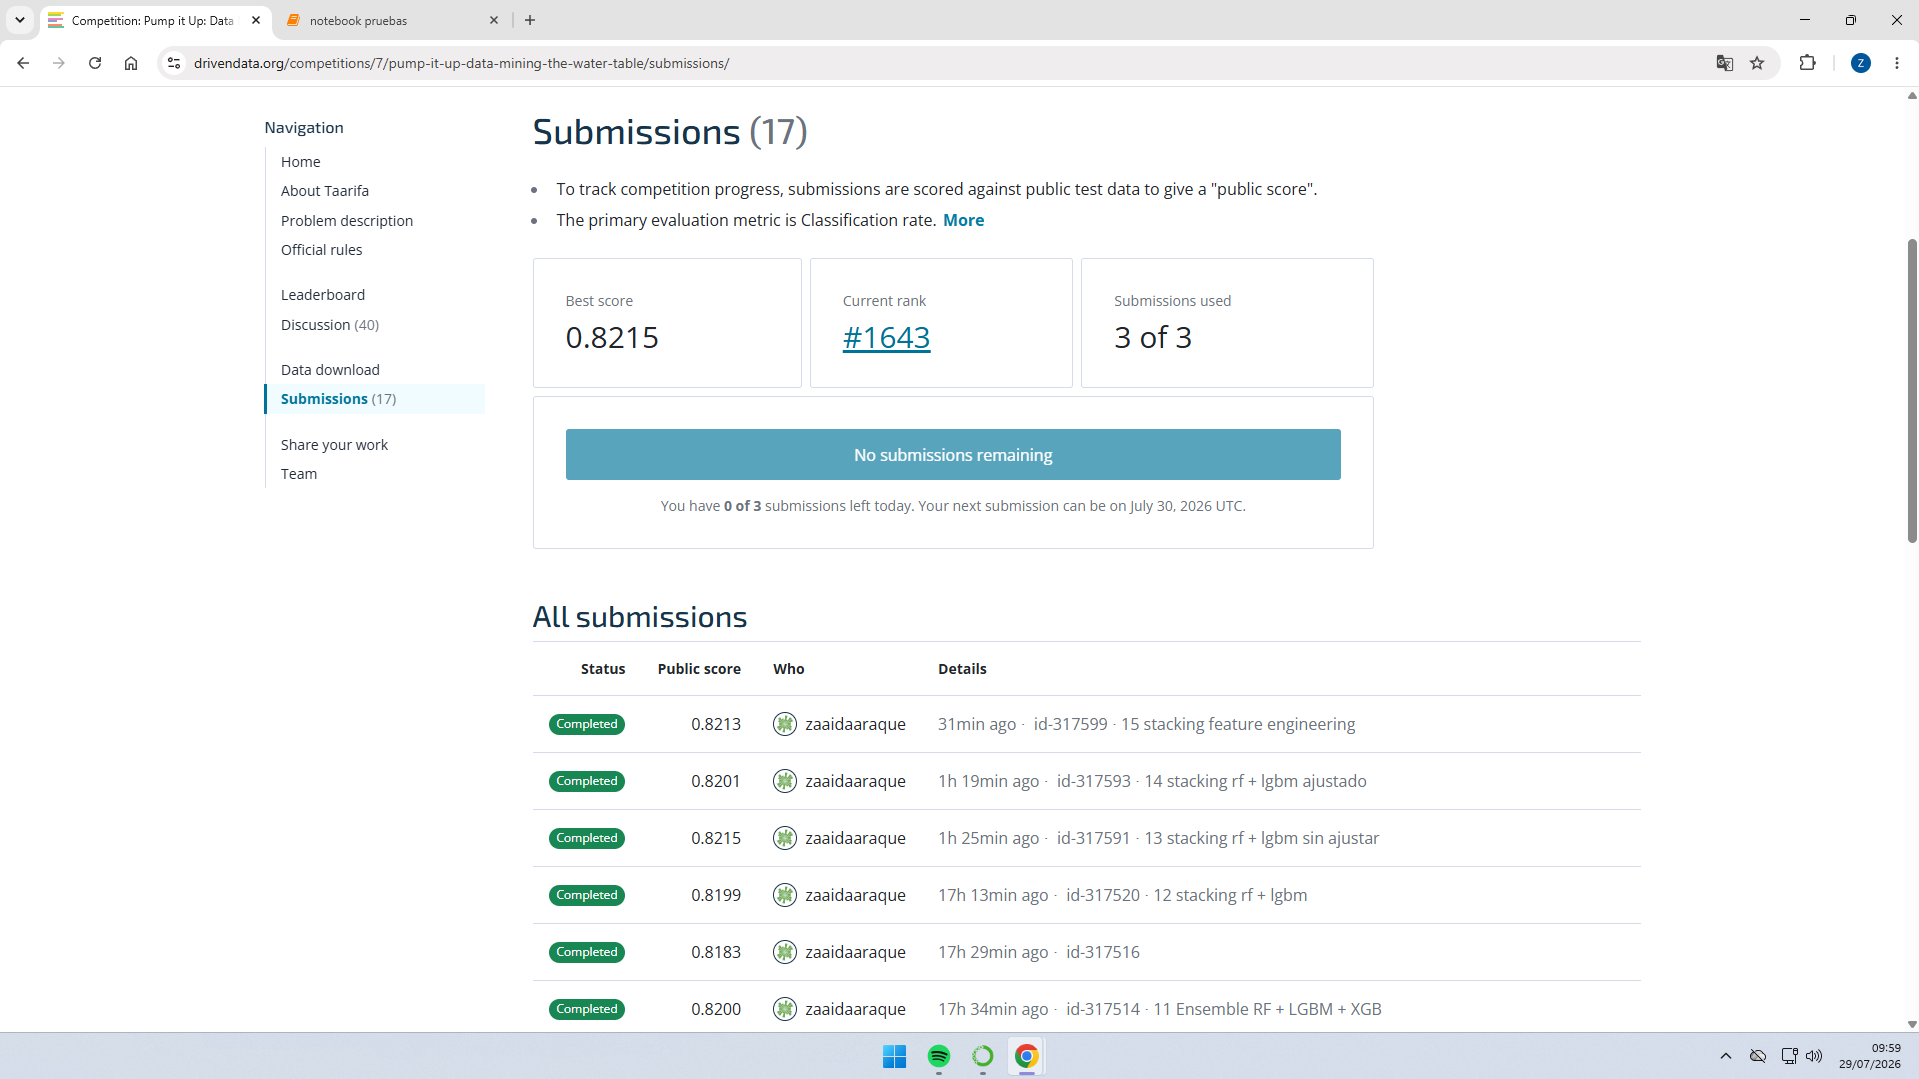